<a href="https://colab.research.google.com/github/Jhay11six/Game-New-Feature-Product-Analysis/blob/main/Game_New_Product_Feature__Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import io
import sqlite3
import seaborn as sns
sns.set()

In [2]:
from google.colab import files
uploaded = files.upload()

Saving iap.csv to iap.csv
Saving daily_activity.csv to daily_activity.csv
Saving ads.csv to ads.csv
Saving matches.csv to matches.csv


In [3]:
csv_files = list(uploaded.keys())

print("Uploaded files:")
for f in csv_files:
    print(f)

Uploaded files:
iap.csv
daily_activity.csv
ads.csv
matches.csv


# **Converting CSV files to SQLite DB**

In [ ]:
db_names = []

for file in csv_files:
    # Read CSV
    df = pd.read_csv(file)

    # Create database name (same as file name)
    db_name = file.replace('.csv', '.db')
    db_names.append(db_name)

    # Connect to SQLite DB
    conn = sqlite3.connect(db_name)

    # Create table name (cleaned file name)
    table_name = file.replace('.csv', '').replace(' ', '_')

    # Write to SQLite
    df.to_sql(table_name, conn, if_exists='replace', index=False)

    conn.close()

    print(f"{file} → {db_name} (table: {table_name}) created successfully")

iap.csv → iap.db (table: iap) created successfully
daily_activity.csv → daily_activity.db (table: daily_activity) created successfully
ads.csv → ads.db (table: ads) created successfully
matches.csv → matches.db (table: matches) created successfully


**Reviewing the SQLite Tables**

In [ ]:
for db_name in db_names:
    conn = sqlite3.connect(db_name)
    # Correctly derive table_name to match how it was created in cell 9TuXCuFE4CQB
    table_name = db_name.replace('.db', '').replace(' ', '_')
    # Explicitly quote the table name to handle potential parsing issues with special characters like '('
    query = f"SELECT * FROM \"{table_name}\"";
    df_from_db = pd.read_sql_query(query, conn)
    print(f"\n--- Head of {table_name}.db ---")
    display(df_from_db.head())
    conn.close()


--- Head of iap.db ---


,user_id,activity_date,product_group,dollar_purchase_value,purchase_number
0,10922,09/07/2025,Perks,1.99,1
1,19995,05/07/2025,Perks,1.99,3
2,18321,19/07/2025,Perks,1.99,8
3,35139,31/07/2025,Perks,4.99,23
4,28901,05/07/2025,Perks,1.99,3



--- Head of daily_activity.db ---


,user_id,activity_date,platform
0,21607,19/07/2025,google
1,17652,22/07/2025,google
2,22306,23/07/2025,Google
3,13306,24/07/2025,Google
4,18752,24/07/2025,Google



--- Head of ads.db ---


,user_id,activity_date,ad_type,impressions,revenue
0,30310,17/07/2025,rewarded,6,0.038
1,13038,25/07/2025,rewarded,11,0.064
2,25157,24/07/2025,rewarded,7,0.054
3,26616,25/07/2025,rewarded,12,0.037
4,28136,11/07/2025,rewarded,30,0.010



--- Head of matches.db ---


,user_id,activity_date,match_type,teams,tier,result,score,match_no
0,11171,30/07/2025,B,1v1,5.0,won,11,5
1,14634,01/07/2025,A,1v1,2.0,abandoned,1,5
2,14518,06/07/2025,B,1v1,5.0,won,11,4
3,18178,24/07/2025,A,1v1,2.0,won,15,2
4,10140,28/07/2025,B,1v1,3.0,lost,4,1


**Daily activities Data Cleaning**

In [ ]:
conn = sqlite3.connect('daily_activity.db')
cursor = conn.cursor()

# Update 'google' to 'Google'
cursor.execute("UPDATE daily_activity SET platform = 'Google' WHERE platform = 'google';")

# Update 'Ios' to 'ios'
cursor.execute("UPDATE daily_activity SET platform = 'ios' WHERE platform = 'Ios';")

conn.commit()
print("Platform column in daily_activity.db updated successfully.")

# Display the updated head to verify
conn = sqlite3.connect('daily_activity.db')
daily_activity_updated_df = pd.read_sql_query("SELECT * FROM daily_activity ", conn)
display(daily_activity_updated_df)
df_daily_distinct = pd.read_sql_query("SELECT DISTINCT * FROM daily_activity", conn)
print("\n--- Distinct entries from daily_activity.db ---")

print(f"Original rows: {pd.read_sql_query('SELECT COUNT(*) FROM daily_activity', conn).iloc[0,0]}, Distinct rows: {len(df_daily_distinct)}")

Platform column in daily_activity.db updated successfully.


,user_id,activity_date,platform
0,21607,19/07/2025,Google
1,17652,22/07/2025,Google
2,22306,23/07/2025,Google
3,13306,24/07/2025,Google
4,18752,24/07/2025,Google
...,...,...,...
533482,19345,17/07/2025,Google
533483,12715,18/07/2025,Google
533484,24819,18/07/2025,Google
533485,9557,19/07/2025,Google



--- Distinct entries from daily_activity.db ---
Original rows: 533487, Distinct rows: 355816


In [ ]:
# Remove Duplicates

conn = sqlite3.connect('daily_activity.db')
sql_query_distinct = """
SELECT DISTINCT
    user_id,
    activity_date,
    platform
FROM
    daily_activity;
"""
daily_activity_deduplicated_df = pd.read_sql_query(sql_query_distinct, conn)

print(f"Shape after removing duplicates (SQL): {daily_activity_deduplicated_df.shape}")
display(daily_activity_deduplicated_df.head())
conn.close()

Shape after removing duplicates (SQL): (355816, 3)


,user_id,activity_date,platform
0,21607,19/07/2025,Google
1,17652,22/07/2025,Google
2,22306,23/07/2025,Google
3,13306,24/07/2025,Google
4,18752,24/07/2025,Google


In [ ]:
# Save daily_activity_deduplicated_df to a SQLite database
conn_daily_activity_deduplicated_df = sqlite3.connect('daily_activity_deduplicated_df.db')

daily_activity_deduplicated_df.to_sql(
    'daily_activity_deduplicated_table',
    conn_daily_activity_deduplicated_df,
    if_exists='replace',
    index=False
)

# Print confirmation and shape
print("daily_activity_deduplicated_df saved to daily_activity_deduplicated_df.db as 'daily_activity_deduplicated_table'")
print(daily_activity_deduplicated_df.shape)

daily_activity_deduplicated_df saved to daily_activity_deduplicated_df.db as 'daily_activity_deduplicated_table'
(355816, 3)


In [ ]:
conn_daily = sqlite3.connect('daily_activity_deduplicated_df.db')

sql_query_platform_counts = """
SELECT
    platform,
    COUNT(user_id) AS user_count, COUNT(DISTINCT user_id) as distinct_user_count
FROM
    daily_activity_deduplicated_table
GROUP BY
    platform;
"""

platform_counts_df = pd.read_sql_query(sql_query_platform_counts, conn_daily)
display(platform_counts_df)


,platform,user_count,distinct_user_count
0,Google,298732,22672
1,ios,57084,5829


**Daily activities visuals**

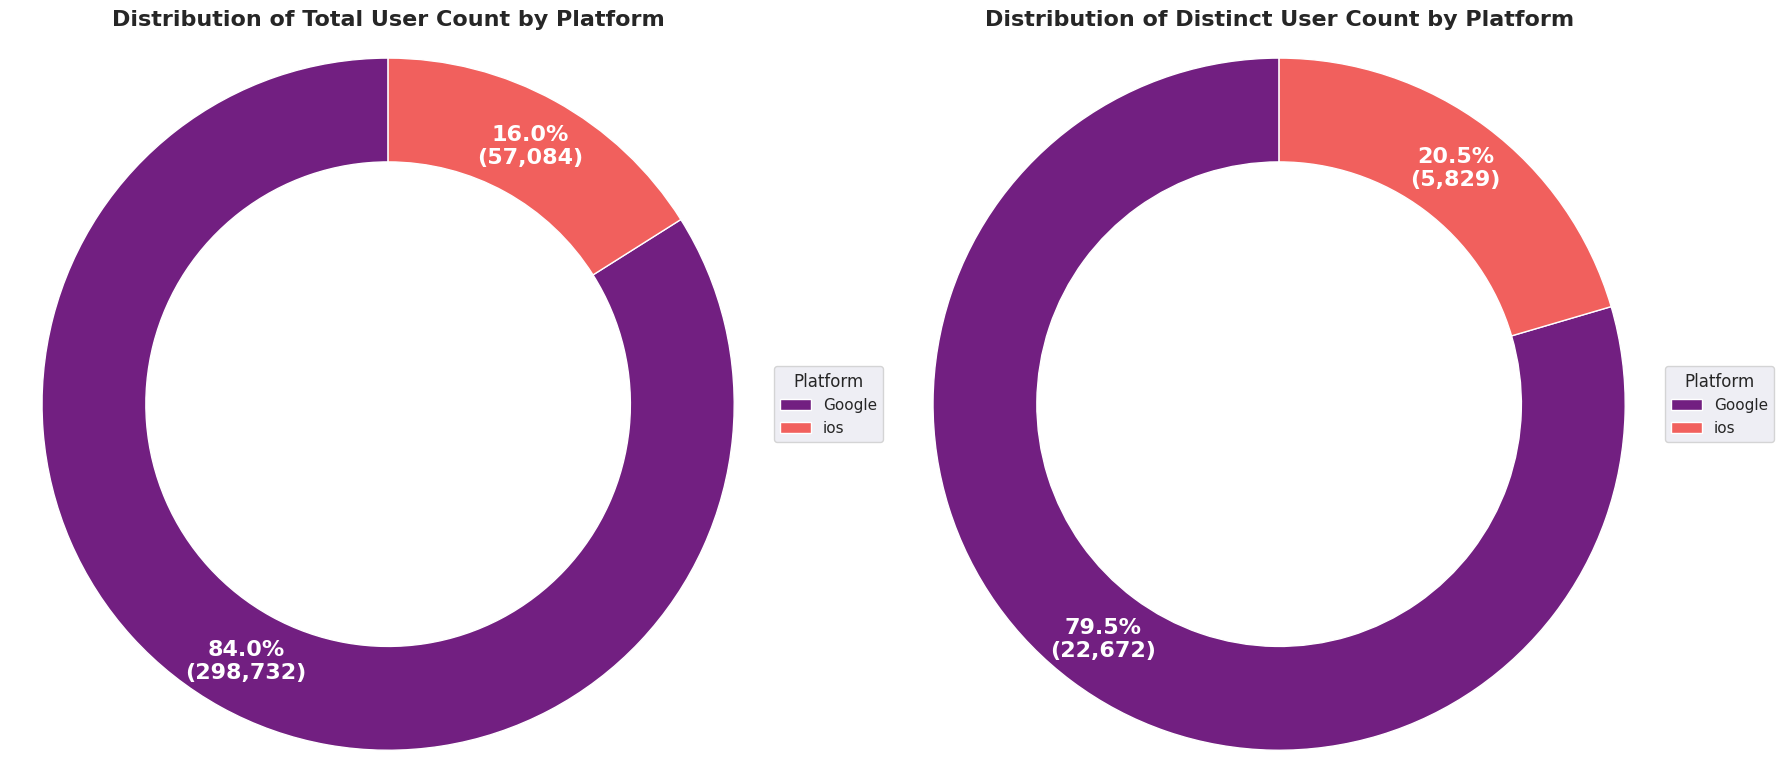

In [ ]:

def autopct_format_donut(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'
    return my_format

# Define a consistent color palette using 'magma'
n_platforms = len(platform_counts_df['platform'])
magma_palette = sns.color_palette('magma', n_colors=n_platforms)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Donut chart for user_count
wedges1, texts1, autotexts1 = axes[0].pie(
    platform_counts_df['user_count'],
    autopct=autopct_format_donut(platform_counts_df['user_count']),
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.3, edgecolor='w'),
    colors=magma_palette
)

axes[0].set_title('Distribution of Total User Count by Platform', fontsize=16, fontweight='bold')
axes[0].axis('equal')
axes[0].legend(wedges1, platform_counts_df['platform'], title='Platform',loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
plt.setp(autotexts1, size=16, weight='bold', color='white')
plt.setp(texts1, size=16, weight='bold')

# Donut chart for distinct_user_count
wedges2, texts2, autotexts2 = axes[1].pie(
    platform_counts_df['distinct_user_count'],
    autopct=autopct_format_donut(platform_counts_df['distinct_user_count']),
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.3, edgecolor='w'),
    colors=magma_palette
)

axes[1].set_title('Distribution of Distinct User Count by Platform', fontsize=16, fontweight='bold')
axes[1].axis('equal')
axes[1].legend(wedges2, platform_counts_df['platform'], title='Platform', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
plt.setp(autotexts2, size=16, weight='bold', color='white')
plt.setp(texts2, size=16, weight='bold')

plt.tight_layout()
plt.show()

**Matches Exploration (Data Manipulation & Visualisation)**

In [ ]:
## Created 2 new variables (first_play_date & days_since_first_play)
conn_matches = sqlite3.connect('matches.db')

sql_query = """
-- Step 1: Standardise date format once
WITH cleaned_data AS (
    SELECT
        user_id,
        match_type,
        teams,
        tier,
        result,
        score,
        match_no,

        -- Convert to proper DATE format (YYYY-MM-DD)
        DATE(substr(activity_date, 7, 4) || '-' ||
             substr(activity_date, 4, 2) || '-' ||
             substr(activity_date, 1, 2)) AS activity_date

    FROM matches
),

-- Step 2: Get first play date per user
user_first_play AS (
    SELECT
        *,
        MIN(activity_date) OVER (PARTITION BY user_id) AS first_play_date
    FROM cleaned_data
)

-- Step 3: Calculate days difference (accurate)
SELECT
    *,

    CAST(
        julianday(activity_date) - julianday(first_play_date)
        AS INTEGER
    ) AS days_since_first_play

FROM user_first_play;
"""

df = pd.read_sql_query(sql_query, conn_matches)
display(df.head(3))
display(df.shape)

,user_id,match_type,teams,tier,result,score,match_no,activity_date,first_play_date,days_since_first_play
0,8321,B,1v1,1.0,lost,5,1,2025-07-19,2025-07-01,18
1,8321,B,1v1,3.0,won,11,13,2025-07-12,2025-07-01,11
2,8321,A,1v1,1.0,won,15,11,2025-07-06,2025-07-01,5


(1048575, 10)

**Feature Adoption rate and Rentention rate analysis**

In [ ]:
#Unique user count for first_play_date
pivot_table_df = df.pivot_table(index='first_play_date', columns='match_type', values='user_id', aggfunc='nunique', fill_value=0)
display(pivot_table_df.head(31))

match_type,A,B,C
first_play_date,,,
2025-07-01,5435,5806,3700
2025-07-02,1556,1697,966
2025-07-03,909,995,516
2025-07-04,741,873,467
2025-07-05,587,640,338
2025-07-06,498,597,283
2025-07-07,463,550,252
2025-07-08,398,457,234
2025-07-09,338,412,198


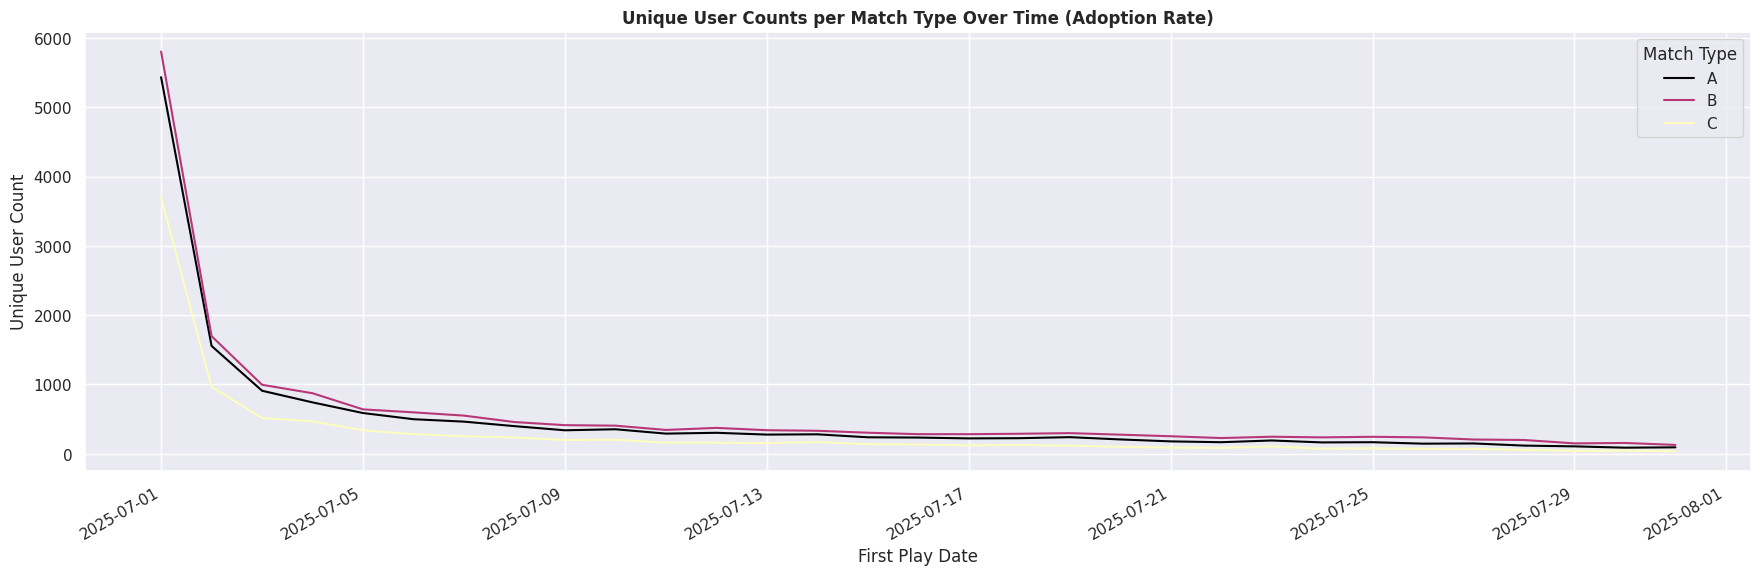

In [ ]:
#Adoption rate Curve

pivot_table_df.index = pd.to_datetime(pivot_table_df.index)
plt.figure(figsize=(18, 6))
colors = plt.colormaps['magma'](np.linspace(0, 1, len(pivot_table_df.columns))) # Using plt.colormaps for recommended approach

for i, column in enumerate(pivot_table_df.columns):
    plt.plot(pivot_table_df.index, pivot_table_df[column], label=column, color=colors[i])

plt.title('Unique User Counts per Match Type Over Time (Adoption Rate)', fontweight='bold')
plt.xlabel('First Play Date')
plt.ylabel('Unique User Count')
plt.legend(title='Match Type')
plt.grid(True)
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

Average Unique Users per Match Type (Adoption Rate):
match_type
A    495.000000
B    574.774194
C    299.161290
dtype: float64

Overall Average Adoption Rate across all Match Types: 456.31


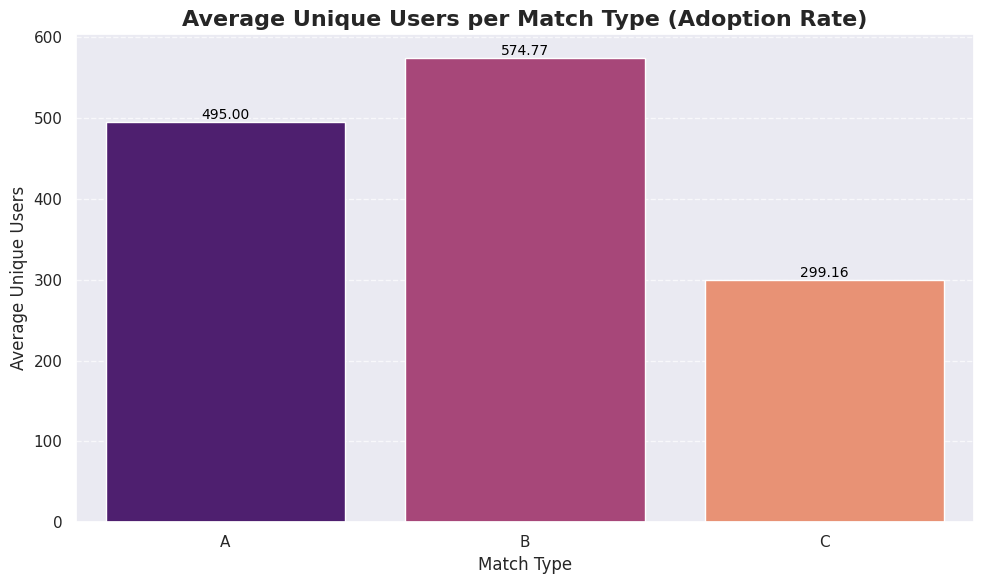

In [ ]:
# Calculate the average unique user count for each match type over the observed period
average_unique_users_per_match_type = pivot_table_df.mean()

# Calculate the overall average adoption rate across all match types
overall_average_adoption_rate = average_unique_users_per_match_type.mean()

print("Average Unique Users per Match Type (Adoption Rate):")
print(average_unique_users_per_match_type)
print(f"\nOverall Average Adoption Rate across all Match Types: {overall_average_adoption_rate:.2f}")

# Convert the Series to a DataFrame for plotting
adoption_rate_df = average_unique_users_per_match_type.reset_index()
adoption_rate_df.columns = ['Match Type', 'Average Unique Users']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Match Type', y='Average Unique Users', data=adoption_rate_df, hue='Match Type', palette='magma', legend=False)

plt.title('Average Unique Users per Match Type (Adoption Rate)', fontsize=16, fontweight='bold')
plt.xlabel('Match Type', fontsize=12)
plt.ylabel('Average Unique Users', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black')

plt.tight_layout()
plt.show()

**Acivation Rate**

In [ ]:
unique_match_types = df['match_type'].unique()

print("Percentage of matches that were NOT abandoned by Match Type (based on total matches):")
for match_type_val in unique_match_types:
    df_filtered_by_match_type = df[df['match_type'] == match_type_val]

    total_matches_match_type = len(df_filtered_by_match_type) # Total matches, not unique users
    abandoned_matches_match_type = df_filtered_by_match_type[df_filtered_by_match_type['result'] == 'abandoned'].shape[0]
    not_abandoned_matches_match_type = total_matches_match_type - abandoned_matches_match_type

    if total_matches_match_type > 0:
        percentage_not_abandoned_matches_match_type = (not_abandoned_matches_match_type / total_matches_match_type) * 100
        print(f"Match Type {match_type_val}: {percentage_not_abandoned_matches_match_type:.2f}%")
    else:
        print(f"Match Type {match_type_val}: No matches found.")

Percentage of matches that were NOT abandoned by Match Type (based on total matches):
Match Type B: 90.73%
Match Type A: 91.06%
Match Type C: 88.82%


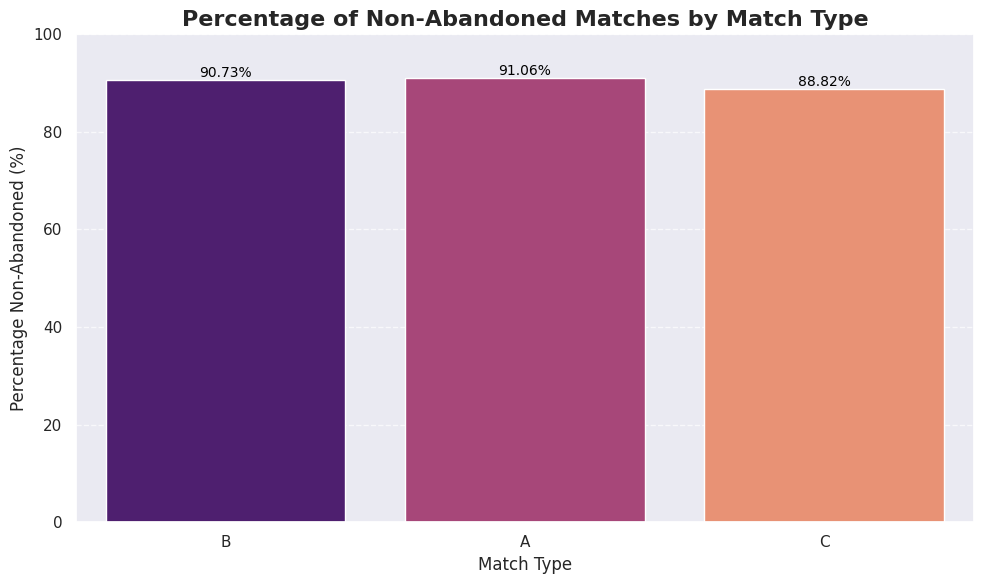

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-calculate the percentages to ensure the data is available for plotting
non_abandoned_percentages = []
for match_type_val in unique_match_types:
    df_filtered_by_match_type = df[df['match_type'] == match_type_val]
    total_matches_match_type = len(df_filtered_by_match_type)
    abandoned_matches_match_type = df_filtered_by_match_type[df_filtered_by_match_type['result'] == 'abandoned'].shape[0]
    not_abandoned_matches_match_type = total_matches_match_type - abandoned_matches_match_type

    if total_matches_match_type > 0:
        percentage_not_abandoned = (not_abandoned_matches_match_type / total_matches_match_type) * 100
        non_abandoned_percentages.append({'Match Type': match_type_val, 'Percentage Non-Abandoned': percentage_not_abandoned})

non_abandoned_df = pd.DataFrame(non_abandoned_percentages)

# Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Match Type', y='Percentage Non-Abandoned', data=non_abandoned_df, hue='Match Type', palette='magma', legend=False)

plt.title('Percentage of Non-Abandoned Matches by Match Type', fontsize=16, fontweight='bold')
plt.xlabel('Match Type', fontsize=12)
plt.ylabel('Percentage Non-Abandoned (%)', fontsize=12)
plt.ylim(0, 100) # Ensure y-axis goes up to 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black')

plt.tight_layout()
plt.show()

**Retention Rate**

In [ ]:
##Create cohorts

df['cohort'] = df['first_play_date']

cohort_data = (
    df.groupby(['cohort', 'days_since_first_play'])['user_id']
    .nunique()
    .reset_index()
)

In [ ]:
#30 Day retention cohort for unique users count (real numbers not %tage)

cohort_pivot = cohort_data.pivot(
    index='cohort',
    columns='days_since_first_play',
    values='user_id'
)

# cohort size = Day 0 users
cohort_size = cohort_pivot[0]
cohort_size

cohort_pivot
cohort_pivot_summary = cohort_pivot[[0, 1, 2,  5, 10, 20, 30]]
print(cohort_pivot_summary)

days_since_first_play      0       1       2       5       10      20      30
cohort                                                                       
2025-07-01             7153.0  4922.0  4642.0  4279.0  4181.0  3659.0  3325.0
2025-07-02             2269.0  1073.0   999.0   929.0   838.0   753.0     NaN
2025-07-03             1340.0   546.0   488.0   464.0   415.0   357.0     NaN
2025-07-04             1173.0   407.0   377.0   335.0   304.0   247.0     NaN
2025-07-05              895.0   303.0   288.0   224.0   212.0   180.0     NaN
2025-07-06              814.0   251.0   227.0   208.0   177.0   177.0     NaN
2025-07-07              751.0   253.0   241.0   193.0   145.0   140.0     NaN
2025-07-08              636.0   223.0   186.0   171.0   140.0   140.0     NaN
2025-07-09              557.0   201.0   158.0   146.0   135.0   109.0     NaN
2025-07-10              551.0   194.0   160.0   124.0   121.0    91.0     NaN
2025-07-11              461.0   172.0   150.0   112.0    97.0   

In [ ]:
#30 Day retention cohort for unique users count (%tage)


cohort_pivot = cohort_data.pivot(
    index='cohort',
    columns='days_since_first_play',
    values='user_id'
)

# cohort size = Day 0 users
cohort_size = cohort_pivot[0]
cohort_size

# retention %
retention = cohort_pivot.divide(cohort_size, axis=0)
retention_summary = retention[[0, 1, 2,  5, 10, 20, 25, 30]]
print(retention_summary.round(3))

days_since_first_play   0      1      2      5      10     20     25     30
cohort                                                                     
2025-07-01             1.0  0.688  0.649  0.598  0.585  0.512  0.482  0.465
2025-07-02             1.0  0.473  0.440  0.409  0.369  0.332  0.305    NaN
2025-07-03             1.0  0.407  0.364  0.346  0.310  0.266  0.271    NaN
2025-07-04             1.0  0.347  0.321  0.286  0.259  0.211  0.198    NaN
2025-07-05             1.0  0.339  0.322  0.250  0.237  0.201  0.191    NaN
2025-07-06             1.0  0.308  0.279  0.256  0.217  0.217  0.182    NaN
2025-07-07             1.0  0.337  0.321  0.257  0.193  0.186    NaN    NaN
2025-07-08             1.0  0.351  0.292  0.269  0.220  0.220    NaN    NaN
2025-07-09             1.0  0.361  0.284  0.262  0.242  0.196    NaN    NaN
2025-07-10             1.0  0.352  0.290  0.225  0.220  0.165    NaN    NaN
2025-07-11             1.0  0.373  0.325  0.243  0.210  0.195    NaN    NaN
2025-07-12  

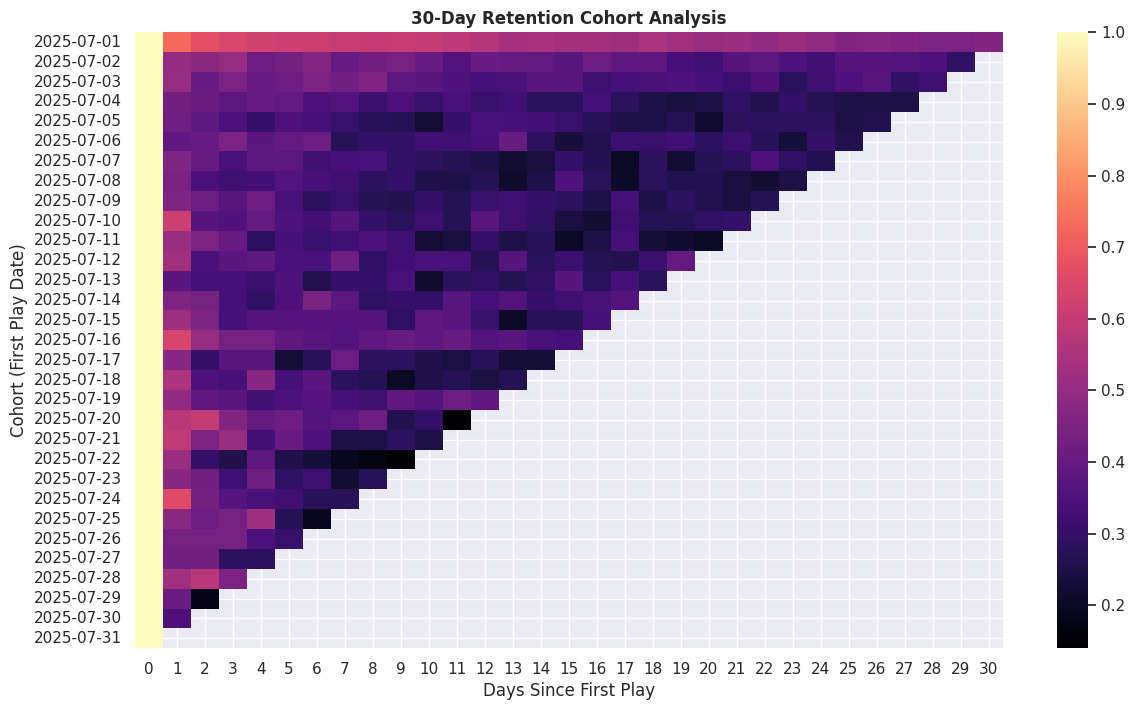

In [ ]:
#Visuals
plt.figure(figsize=(14,8))
sns.heatmap(retention, annot=False, cmap='magma')
plt.title("30-Day Retention Cohort Analysis", fontweight='bold')
plt.xlabel("Days Since First Play")
plt.ylabel("Cohort (First Play Date)")
plt.show()

Cohort analysis for match type: C
days_since_first_play   0      1      2      5      10     20     25     30
cohort                                                                     
2025-07-01             1.0  0.730  0.670  0.617  0.599  0.509  0.462  0.461
2025-07-02             1.0  0.499  0.481  0.432  0.405  0.324  0.367    NaN
2025-07-03             1.0  0.506  0.406  0.417  0.376  0.332  0.351    NaN
2025-07-04             1.0  0.426  0.410  0.393  0.307  0.246  0.250    NaN
2025-07-05             1.0  0.420  0.387  0.354  0.227  0.215  0.249    NaN
2025-07-06             1.0  0.392  0.406  0.399  0.322  0.287  0.259    NaN
2025-07-07             1.0  0.455  0.403  0.381  0.284  0.269    NaN    NaN
2025-07-08             1.0  0.443  0.344  0.361  0.254  0.262    NaN    NaN
2025-07-09             1.0  0.454  0.417  0.343  0.296  0.259    NaN    NaN
2025-07-10             1.0  0.615  0.365  0.346  0.317  0.288    NaN    NaN
2025-07-11             1.0  0.512  0.452  0.333  0.226

<Figure size 1600x800 with 0 Axes>

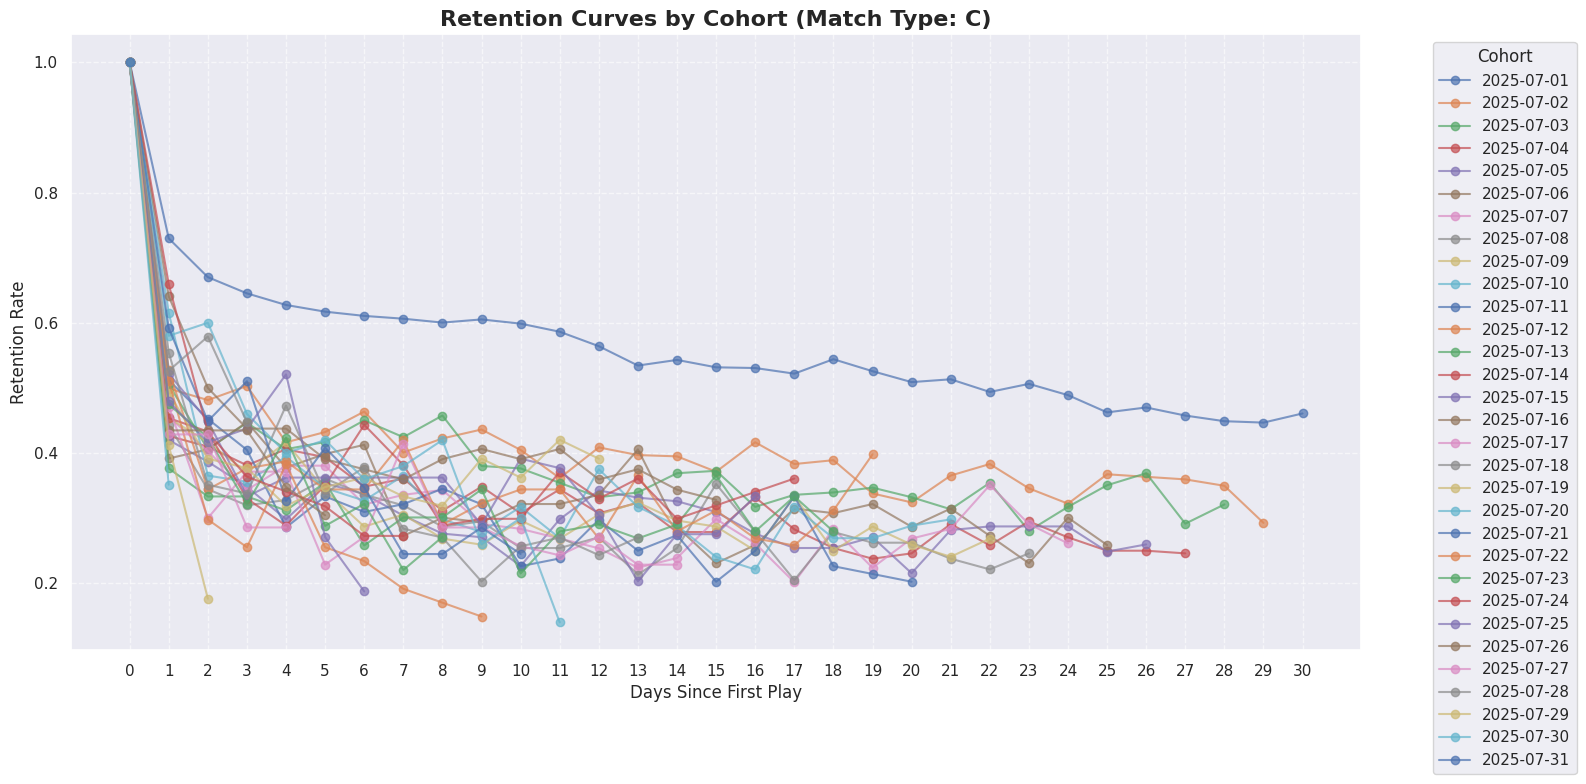

In [ ]:
##Create cohorts for each match_type (%TAGE)
# For example, to filter by 'A', you would change variable line below to 'A' not 'C' vice- versa
selected_match_type = 'C'

if 'selected_match_type' in locals():
    df_filtered_by_match_type = df[df['match_type'] == selected_match_type].copy()
    df_to_use = df_filtered_by_match_type
    print(f"Cohort analysis for match type: {selected_match_type}")
else:
    df_to_use = df
    print("Cohort analysis for all match types")

df_to_use['cohort'] = df_to_use['first_play_date']

cohort_data = (
    df_to_use.groupby(['cohort', 'days_since_first_play'])['user_id']
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_data.pivot(
    index='cohort',
    columns='days_since_first_play',
    values='user_id'
)

# cohort size = Day 0 users
cohort_size = cohort_pivot[0]
cohort_size

# retention %
retention = cohort_pivot.divide(cohort_size, axis=0)
retention_summary = retention[[0, 1, 2,  5, 10, 20, 25, 30]]
print(retention_summary.round(3))

# Plotting the retention curves
plt.figure(figsize=(16, 8))
retention.T.plot(kind='line', figsize=(16, 8), marker='o', alpha=0.7)
plt.title(f'Retention Curves by Cohort (Match Type: {selected_match_type if 'selected_match_type' in locals() else 'All'})', fontsize=16, fontweight='bold')
plt.xlabel('Days Since First Play', fontsize=12)
plt.ylabel('Retention Rate', fontsize=12)
plt.xticks(retention.columns)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cohort', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#Average 30-day retention for the diverse match type

unique_match_types = df['match_type'].unique()

average_30_day_retention_by_match_type = {}

for match_type_val in unique_match_types:
    df_filtered_by_match_type = df[df['match_type'] == match_type_val].copy()
    df_to_use = df_filtered_by_match_type

    df_to_use['cohort'] = df_to_use['first_play_date']

    cohort_data = (
        df_to_use.groupby(['cohort', 'days_since_first_play'])['user_id']
        .nunique()
        .reset_index()
    )
    cohort_pivot = cohort_data.pivot(
        index='cohort',
        columns='days_since_first_play',
        values='user_id'
    )

    cohort_size = cohort_pivot[0]
    retention = cohort_pivot.divide(cohort_size, axis=0)

    # Calculate the average 30-day retention for the current match type
    if 30 in retention.columns:
        average_30_day_retention = retention[30].mean()
        average_30_day_retention_by_match_type[match_type_val] = average_30_day_retention
    else:
        average_30_day_retention_by_match_type[match_type_val] = None # Or np.nan

print("Average 30-day Retention Rate by Match Type:")
for match_type, avg_retention in average_30_day_retention_by_match_type.items():
    if avg_retention is not None:
        print(f"Match Type {match_type}: {avg_retention:.3f}")
    else:
        print(f"Match Type {match_type}: Not enough data for 30-day retention")

Average 30-day Retention Rate by Match Type:
Match Type B: 0.436
Match Type A: 0.482
Match Type C: 0.461


In [ ]:
#Average 30-day retention for the diverse match type

unique_match_types = df['match_type'].unique()

average_30_day_retention_by_match_type = {}

for match_type_val in unique_match_types:
    df_filtered_by_match_type = df[df['match_type'] == match_type_val].copy()
    df_to_use = df_filtered_by_match_type

    df_to_use['cohort'] = df_to_use['first_play_date']

    cohort_data = (
        df_to_use.groupby(['cohort', 'days_since_first_play'])['user_id']
        .nunique()
        .reset_index()
    )
    cohort_pivot = cohort_data.pivot(
        index='cohort',
        columns='days_since_first_play',
        values='user_id'
    )

    cohort_size = cohort_pivot[0]
    retention = cohort_pivot.divide(cohort_size, axis=0)

    # Calculate the average 30-day retention for the current match type
    if 30 in retention.columns:
        average_30_day_retention = retention[30].mean()
        average_30_day_retention_by_match_type[match_type_val] = average_30_day_retention
    else:
        average_30_day_retention_by_match_type[match_type_val] = None # Or np.nan

print("Average 30-day Retention Rate by Match Type:")
for match_type in sorted(average_30_day_retention_by_match_type.keys()):
    avg_retention = average_30_day_retention_by_match_type[match_type]
    if avg_retention is not None:
        print(f"Match Type {match_type}: {avg_retention:.3f}")
    else:
        print(f"Match Type {match_type}: Not enough data for 30-day retention")

Average 30-day Retention Rate by Match Type:
Match Type A: 0.482
Match Type B: 0.436
Match Type C: 0.461


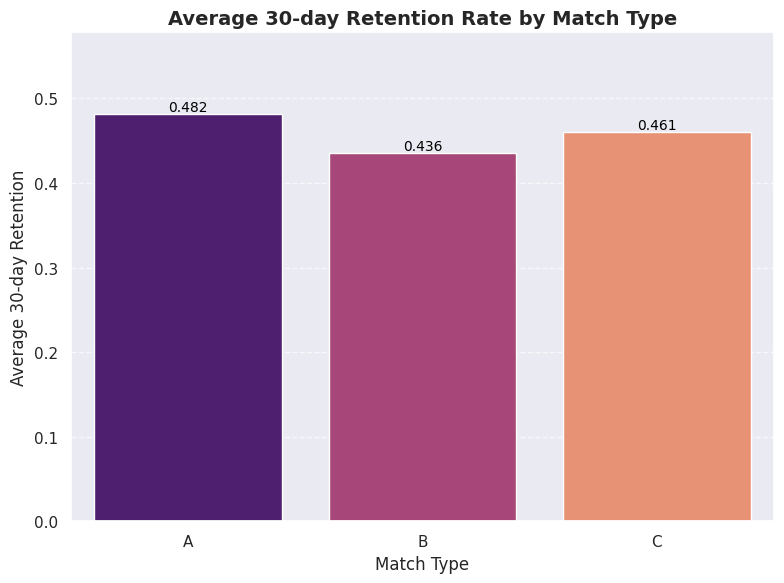

In [ ]:
avg_retention_df = pd.DataFrame(average_30_day_retention_by_match_type.items(), columns=['Match Type', 'Average 30-day Retention'])
avg_retention_df = avg_retention_df.sort_values(by='Match Type').reset_index(drop=True)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Match Type', y='Average 30-day Retention', data=avg_retention_df, hue='Match Type', palette='magma', legend=False)

plt.title('Average 30-day Retention Rate by Match Type', fontsize=14, fontweight='bold')
plt.xlabel('Match Type', fontsize=12)
plt.ylabel('Average 30-day Retention', fontsize=12)
plt.ylim(0, avg_retention_df['Average 30-day Retention'].max() * 1.2) # Adjust y-limit for labels

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Engagement Analysis**

### Overall Team Performance (Across All Match Types)


--- Unique and Total users per Match Type ---


,match_type,unique_user_count,total_user_count
0,A,15345,412097
1,B,17818,429219
2,C,9274,207259


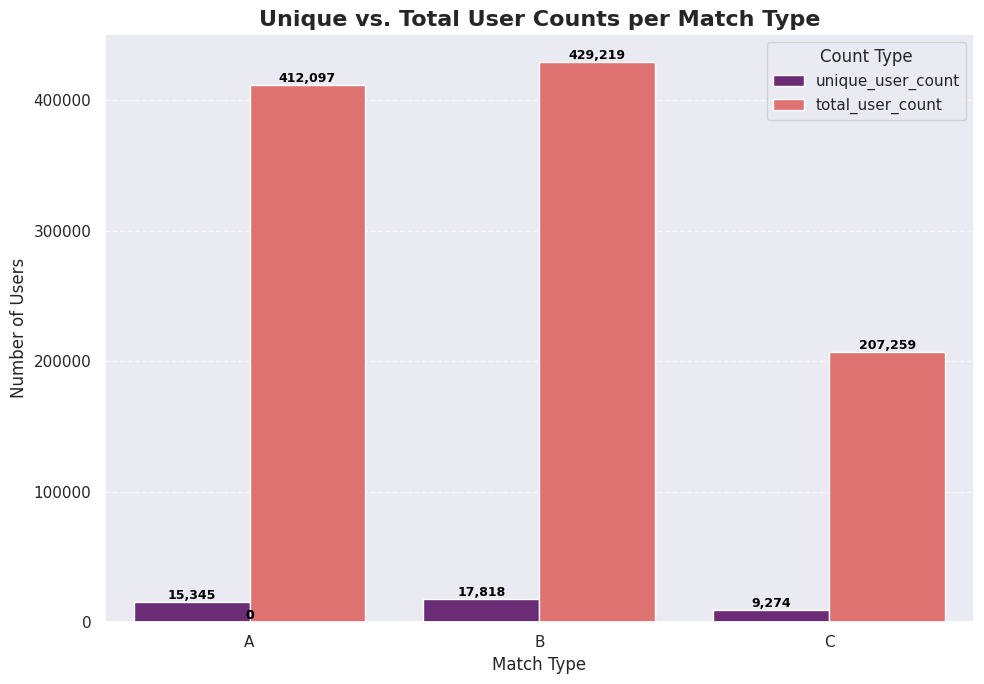

In [ ]:
#Match_type counts

users_per_match_type_df = df.groupby('match_type').agg(
    unique_user_count=('user_id', 'nunique'),
    total_user_count=('user_id', 'count')
).reset_index()

print("\n--- Unique and Total users per Match Type ---")
display(users_per_match_type_df)

# Prepare data for plotting
plot_df_counts = users_per_match_type_df.melt(id_vars=['match_type'],
                                              value_vars=['unique_user_count', 'total_user_count'],
                                              var_name='count_type',
                                              value_name='user_count')

plt.figure(figsize=(10, 7))
ax = sns.barplot(x='match_type', y='user_count', hue='count_type', data=plot_df_counts, palette='magma')

# Add data labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=9, color='black', fontweight='bold')

plt.title('Unique vs. Total User Counts per Match Type', fontsize=16, fontweight='bold')
plt.xlabel('Match Type', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Count Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Result Rates per Match Type ---


result,win_rate,loss_rate,abandon_rate
match_type,,,
A,49.94,41.12,8.94
B,51.15,39.57,9.27
C,51.06,37.76,11.18


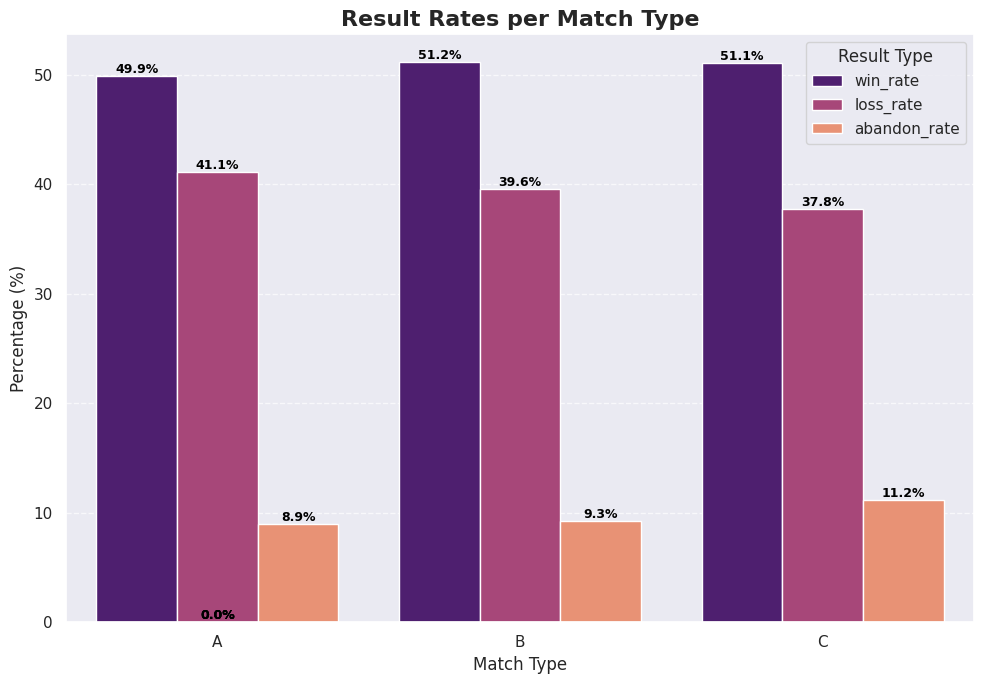

In [ ]:
#Result Rates per Match Type'

result_counts_pivot = df.groupby(['match_type', 'result']).size().unstack(fill_value=0)

total_matches_per_match_type = result_counts_pivot.sum(axis=1)

# Calculate rates
result_counts_pivot['win_rate'] = (result_counts_pivot['won'] / total_matches_per_match_type) * 100
result_counts_pivot['loss_rate'] = (result_counts_pivot['lost'] / total_matches_per_match_type) * 100
result_counts_pivot['abandon_rate'] = (result_counts_pivot['abandoned'] / total_matches_per_match_type) * 100

# Display the pivot table with rates
print("--- Result Rates per Match Type ---")
display(result_counts_pivot[['win_rate', 'loss_rate', 'abandon_rate']].round(2))

# Prepare data for plotting
plot_df_rates = result_counts_pivot[['win_rate', 'loss_rate', 'abandon_rate']].reset_index().melt(
    id_vars='match_type',
    var_name='rate_type',
    value_name='percentage'
)

plt.figure(figsize=(10, 7))
ax = sns.barplot(x='match_type', y='percentage', hue='rate_type', data=plot_df_rates, palette='magma')

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=9, color='black', fontweight='bold')

plt.title('Result Rates per Match Type', fontsize=16, fontweight='bold')
plt.xlabel('Match Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Result Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
pivot_table_teams_results = df.pivot_table(
    index='teams',
    columns='result',
    values='user_id',
    aggfunc='count',
    fill_value=0
)

# Calculate percentages
total_matches_per_team = pivot_table_teams_results.sum(axis=1)
percentage_pivot_table = pivot_table_teams_results.div(total_matches_per_team, axis=0) * 100

# Create a combined pivot table with counts and percentages
combined_pivot_table = pd.DataFrame(index=pivot_table_teams_results.index)

for col in pivot_table_teams_results.columns:
    combined_pivot_table[col] = pivot_table_teams_results[col].astype(str) + ' (' + percentage_pivot_table[col].round(2).astype(str) + '%)'

display(combined_pivot_table)

,abandoned,lost,won
teams,,,
1v1,86754 (9.41%),370550 (40.17%),465053 (50.42%)
2v2,11475 (10.12%),46862 (41.34%),55022 (48.54%)
bot_match,1596 (12.41%),151 (1.17%),11112 (86.41%)


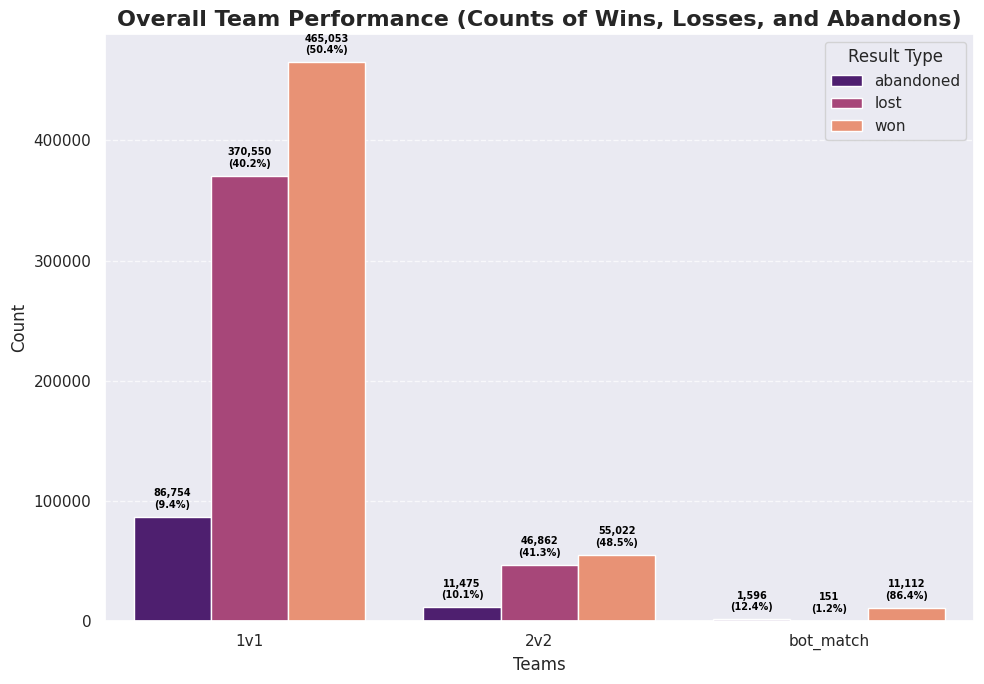

In [ ]:
#Visuals

overall_team_performance_plot = pivot_table_teams_results.reset_index().melt(
    id_vars='teams',
    var_name='result_type',
    value_name='count'
)

# Calculate percentages for data labels
total_matches_per_team = pivot_table_teams_results.sum(axis=1)
percentage_pivot_table = pivot_table_teams_results.div(total_matches_per_team, axis=0) * 100

plt.figure(figsize=(10, 7))
ax = sns.barplot(x='teams', y='count', hue='result_type', data=overall_team_performance_plot, palette='magma')

# Get unique teams and result types in the order they appear on the plot
teams_on_plot = overall_team_performance_plot['teams'].unique()
result_types_on_plot = overall_team_performance_plot['result_type'].unique()

# Add data labels (count and percentage)
for i, container in enumerate(ax.containers): # Iterate over hue categories (result_type)
    result_type = result_types_on_plot[i] # Get the current result_type
    for j, p in enumerate(container.patches): # Iterate over bars within this hue category
        team_name = teams_on_plot[j] # Get the team name corresponding to this bar's position

        # Check if team_name exists in percentage_pivot_table.index
        if team_name in percentage_pivot_table.index:
            percentage = percentage_pivot_table.loc[team_name, result_type]
            ax.annotate(f'{int(p.get_height()):,}\n({percentage:.1f}%)',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom',
                        fontsize=7, color='black', fontweight='bold', xytext=(0, 5), textcoords='offset points')
        else:
            ax.annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom',
                        fontsize=7, color='black', fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.title('Overall Team Performance (Counts of Wins, Losses, and Abandons)', fontsize=16, fontweight='bold')
plt.xlabel('Teams', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Result Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- Unique and Total users per Tier ---


,tier,unique_user_count,total_user_count
0,1.0,14309,170434
1,2.0,15465,268470
2,3.0,15000,185112
3,4.0,6603,79780
4,5.0,12215,163311
5,6.0,9275,123681
6,7.0,3365,33490
7,8.0,3236,18909
8,9.0,728,2878
9,10.0,315,1310


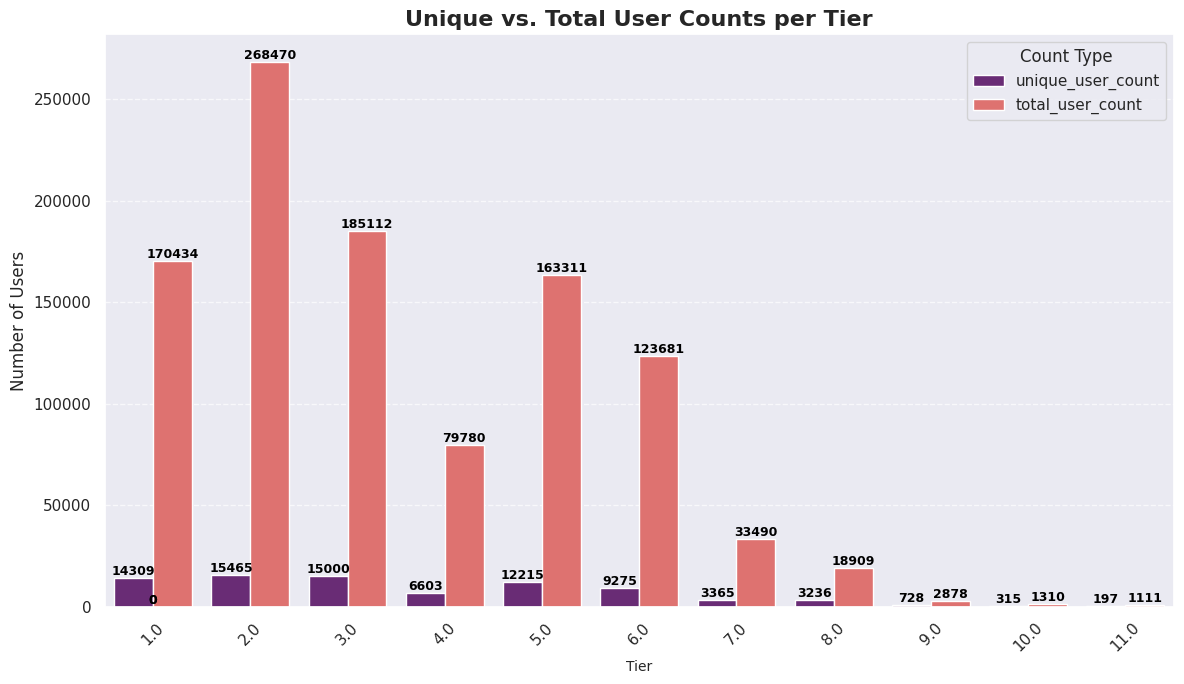

In [ ]:
#Tier Performance Analysis
users_per_tier = df.groupby('tier').agg(
    unique_user_count=('user_id', 'nunique'),
    total_user_count=('user_id', 'count')
).reset_index()

print("\n--- Unique and Total users per Tier ---")
display(users_per_tier)

# plotting
plot_df = users_per_tier.melt(id_vars=['tier'],
                              value_vars=['unique_user_count', 'total_user_count'],
                              var_name='count_type',
                              value_name='user_count')

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='tier', y='user_count', hue='count_type', data=plot_df, palette='magma')

# data labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=9, color='black', fontweight='bold')

plt.title('Unique vs. Total User Counts per Tier', fontsize=16, fontweight='bold')
plt.xlabel('Tier', fontsize=10)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Count Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

match_type,A,B,C
tier,,,
1.0,43117,88561,38756
2.0,108835,100098,59537
3.0,75667,67975,41470
4.0,36843,42937,0
5.0,69925,59596,33790
6.0,52755,47293,23633
7.0,18212,15278,0
8.0,5788,6084,7037
9.0,498,763,1617


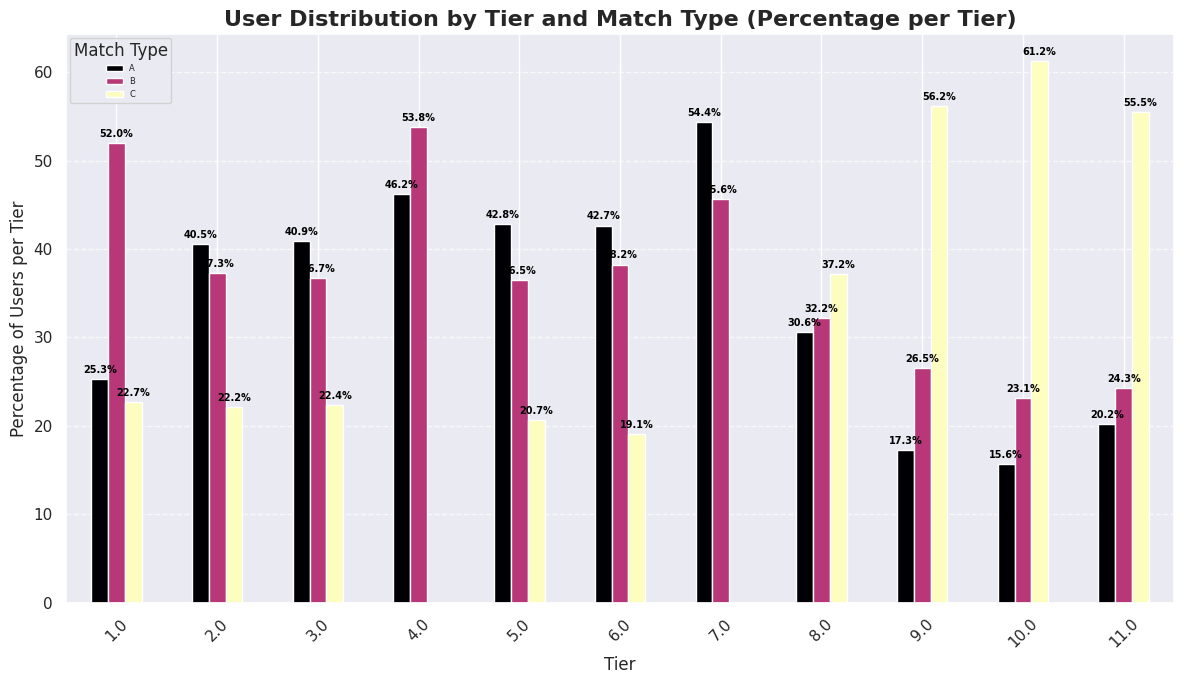

In [ ]:
#tier_match_type performance
pivot_table_tier_match_type = df.pivot_table(index='tier',
                                             columns='match_type',
                                             values='user_id',
                                             aggfunc='count',
                                             fill_value=0)
display(pivot_table_tier_match_type)

#plotting
percentage_df = pivot_table_tier_match_type.div(pivot_table_tier_match_type.sum(axis=1), axis=0) * 100

ax = percentage_df.plot(kind='bar', figsize=(12, 7), colormap='magma')

#labels
for i, container in enumerate(ax.containers):
    match_type = pivot_table_tier_match_type.columns[i]
    labels = []
    for j, patch in enumerate(container.patches):
        if pivot_table_tier_match_type.iloc[j, i] > 0:
            percentage = percentage_df.iloc[j, i]
            labels.append(f'{percentage:.1f}%')
        else:
            labels.append('')
    ax.bar_label(container, labels=labels, label_type='edge', padding=3, fontsize=7, color='black', fontweight='bold')

plt.title('User Distribution by Tier and Match Type (Percentage per Tier)', fontsize=16, fontweight='bold')
plt.xlabel('Tier', fontsize=12)
plt.ylabel('Percentage of Users per Tier', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Match Type', fontsize=6, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

result,abandoned,lost,won
tier,,,
1.0,19009,62423,89002
2.0,24083,107825,136562
3.0,15419,74825,94868
4.0,8187,32555,39038
5.0,14820,65270,83221
6.0,11165,50835,61681
7.0,3276,14261,15953
8.0,2638,7923,8348
9.0,559,974,1345


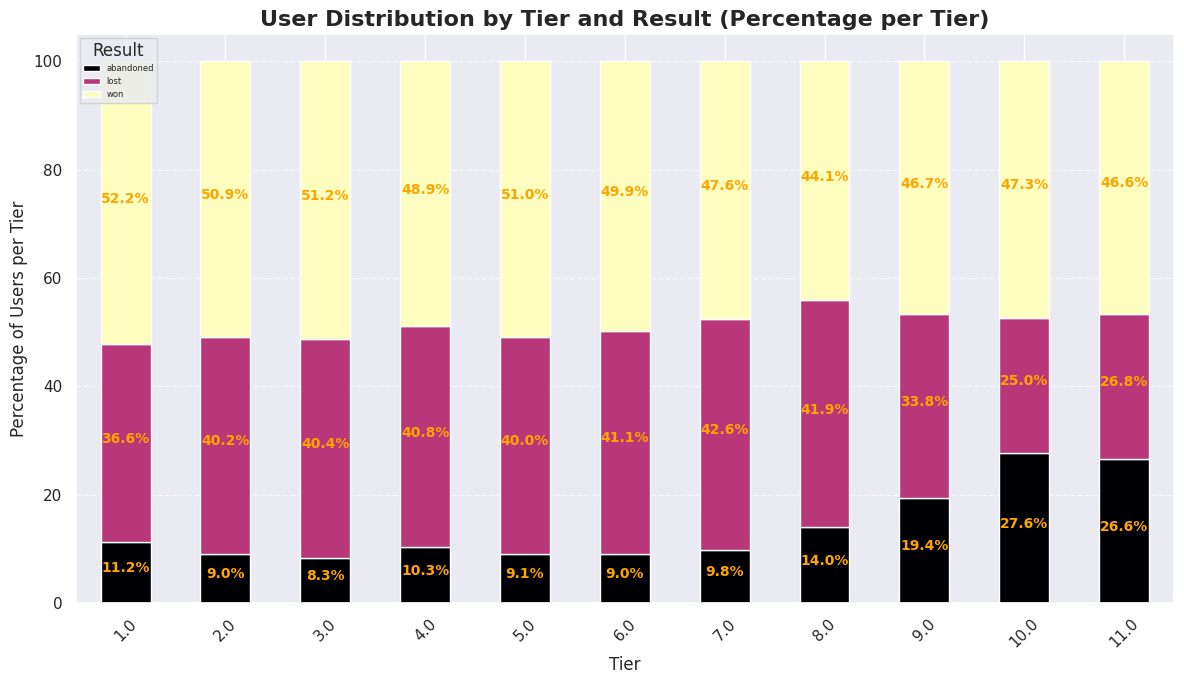

In [ ]:
#Tier_result analysis

pivot_table_tier_result = df.pivot_table(index='tier',
                                         columns='result',
                                         values='user_id',
                                         aggfunc='count',
                                         fill_value=0)
display(pivot_table_tier_result)

#plotting
percentage_result_df = pivot_table_tier_result.div(pivot_table_tier_result.sum(axis=1), axis=0) * 100

ax = percentage_result_df.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='magma')

#labels
for container in ax.containers:
    labels = []
    for patch in container.patches:
        width = patch.get_width()
        height = patch.get_height()
        if height > 0: # Only label non-zero segments
            labels.append(f'{height:.1f}%')
        else:
            labels.append('')
    ax.bar_label(container, labels=labels, label_type='center', padding=3, fontsize=10, color='orange', fontweight='bold')

plt.title('User Distribution by Tier and Result (Percentage per Tier)', fontsize=16, fontweight='bold')
plt.xlabel('Tier', fontsize=12)
plt.ylabel('Percentage of Users per Tier', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Result', fontsize=6, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

teams,1v1,2v2,bot_match,All
match_type,,,,
A,354411,55083,2603,412097
B,362024,58276,8919,429219
C,205922,0,1337,207259
All,922357,113359,12859,1048575


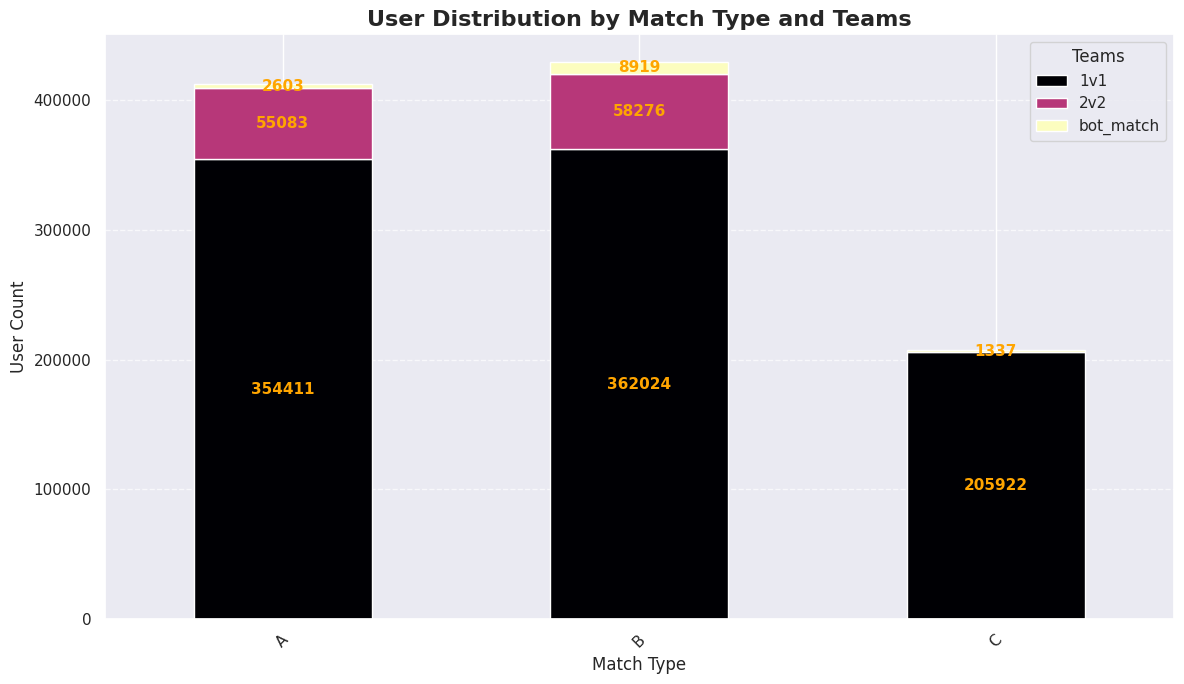

In [ ]:
#Teams_performance

match_type_teams_user_count = df.groupby(['match_type', 'teams'])['user_id'].count().reset_index(name='user_count')
pivot_table_match_type_teams = match_type_teams_user_count.pivot_table(
    index='match_type',
    columns='teams',
    values='user_count',
    aggfunc='sum',
    margins=True,
    fill_value=0 # Fill NaN values with 0
)
display(pivot_table_match_type_teams)
#plotting
ax = pivot_table_match_type_teams.drop('All', axis=1).drop('All', axis=0).plot(kind='bar', stacked=True, figsize=(12, 7), colormap='magma')
plt.title('User Distribution by Match Type and Teams', fontsize=16, fontweight='bold')
plt.xlabel('Match Type', fontsize=12)
plt.ylabel('User Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Teams')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# data labels
for container in ax.containers:
    labels = [f'{int(patch.get_height())}' if patch.get_height() > 0 else '' for patch in container.patches]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=11, color='orange', fontweight='bold')

plt.tight_layout()
plt.show()

**Each Match Type Performance (Teams vs. Results)**

In [ ]:
#Unique user

unique_match_types = df['match_type'].unique()

for match_type_val in unique_match_types:
    df_filtered = df[df['match_type'] == match_type_val]

    pivot_table = df_filtered.pivot_table(
        index='teams',
        columns='result',
        values='user_id',
        aggfunc='nunique',
        fill_value=0
    )
    print(f"\n--- Pivot Table for Match Type: {match_type_val} ---")
    display(pivot_table)


--- Pivot Table for Match Type: B ---


result,abandoned,lost,won
teams,,,
1v1,6924,12706,12745
2v2,1573,3926,3306
bot_match,839,127,3726



--- Pivot Table for Match Type: A ---


result,abandoned,lost,won
teams,,,
1v1,6858,11803,11735
2v2,1524,3795,3332
bot_match,342,13,1281



--- Pivot Table for Match Type: C ---


result,abandoned,lost,won
teams,,,
1v1,4230,7163,7310
bot_match,103,1,668


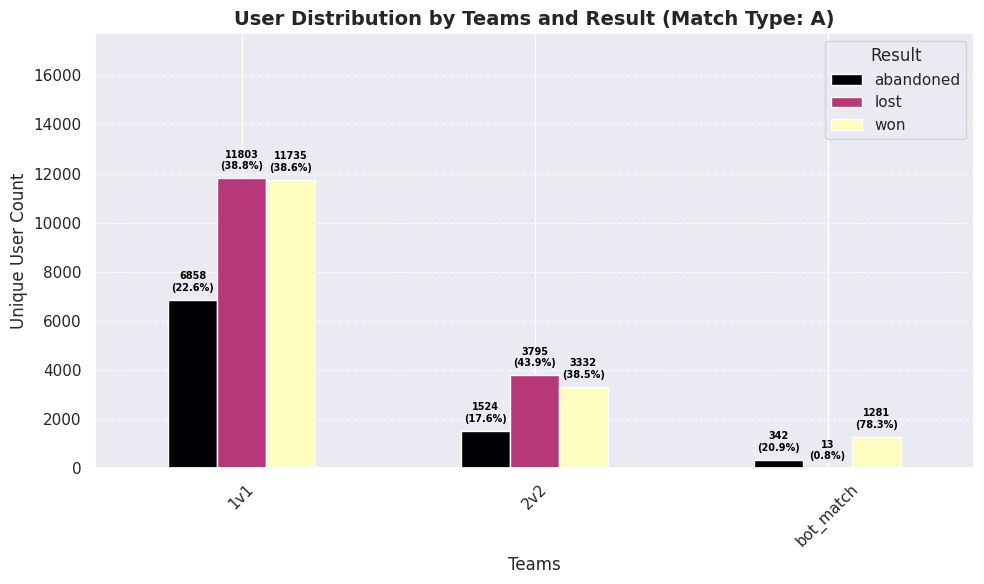

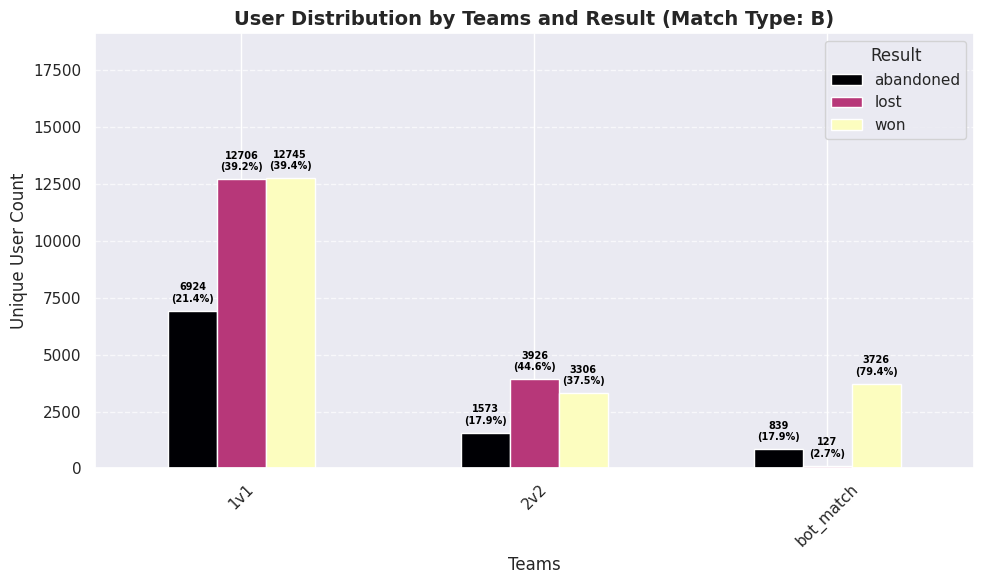

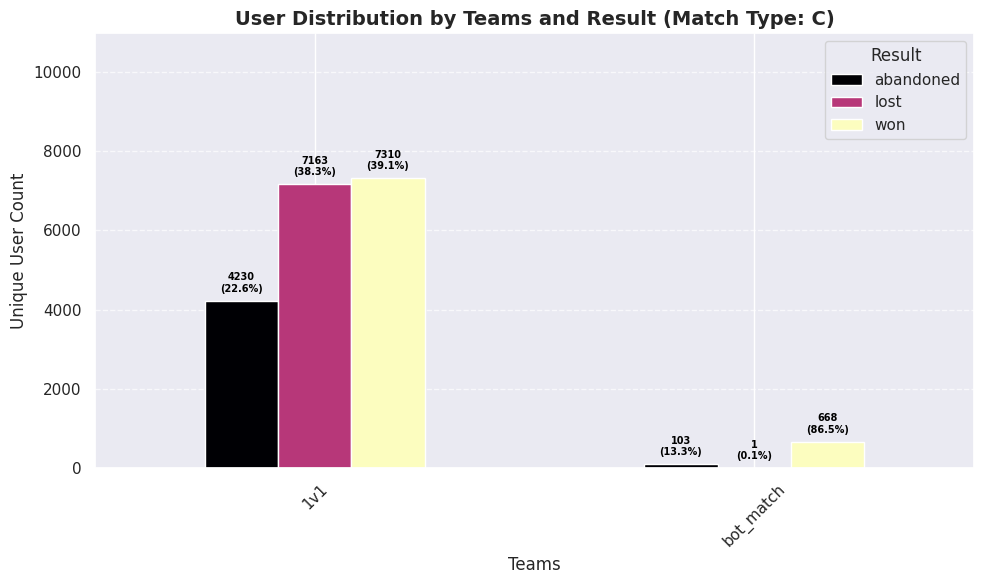

In [ ]:
#Unique user Visuals

unique_match_types = sorted(df['match_type'].unique())

for match_type_val in unique_match_types:
    df_filtered = df[df['match_type'] == match_type_val]

    pivot_table = df_filtered.pivot_table(
        index='teams',
        columns='result',
        values='user_id',
        aggfunc='nunique',
        fill_value=0
    )

    # Calculate percentages for data labels
    total_users_per_team = pivot_table.sum(axis=1)
    percentage_table = pivot_table.div(total_users_per_team, axis=0) * 100

    # Plotting
    ax = pivot_table.plot(kind='bar', stacked=False, figsize=(10, 6), colormap='magma')
    plt.title(f'User Distribution by Teams and Result (Match Type: {match_type_val})', fontsize=14, fontweight='bold')
    plt.xlabel('Teams', fontsize=12)
    plt.ylabel('Unique User Count', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Result')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Adjust y-axis limit to create space for labels
    max_y = pivot_table.max().max()
    ax.set_ylim(0, max_y * 1.5) # Increased y-limit by 50% to make more space for labels

    # Add data labels
    for i, container in enumerate(ax.containers):
        result_col_name = pivot_table.columns[i]
        labels = []
        for j, patch in enumerate(container.patches):
            height = patch.get_height()
            if height > 0:
                team_name = pivot_table.index[j]
                percentage = percentage_table.loc[team_name, result_col_name]
                labels.append(f'{int(height)}\n({percentage:.1f}%)')
            else:
                labels.append('')
        ax.bar_label(container, labels=labels, label_type='edge', padding=5, fontsize=7, color='black', fontweight='bold') # Increased padding slightly

    plt.tight_layout()
    plt.show()

In [ ]:
#Total user

unique_match_types = df['match_type'].unique()

for match_type_val in unique_match_types:
    df_filtered = df[df['match_type'] == match_type_val]

    pivot_table = df_filtered.pivot_table(
        index='teams',
        columns='result',
        values='user_id',
        aggfunc='count',
        fill_value=0
    )
    print(f"\n--- Pivot Table for Match Type: {match_type_val} ---")
    display(pivot_table)



--- Pivot Table for Match Type: B ---


result,abandoned,lost,won
teams,,,
1v1,32216,146340,183468
2v2,6533,23374,28369
bot_match,1058,136,7725



--- Pivot Table for Match Type: A ---


result,abandoned,lost,won
teams,,,
1v1,31494,145945,176972
2v2,4942,23488,26653
bot_match,412,14,2177



--- Pivot Table for Match Type: C ---


result,abandoned,lost,won
teams,,,
1v1,23044,78265,104613
bot_match,126,1,1210


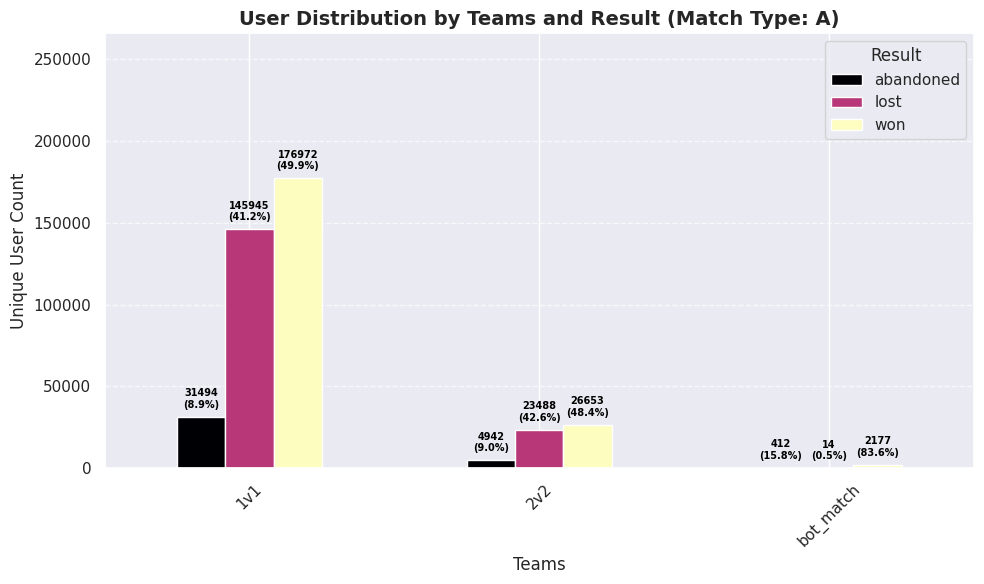

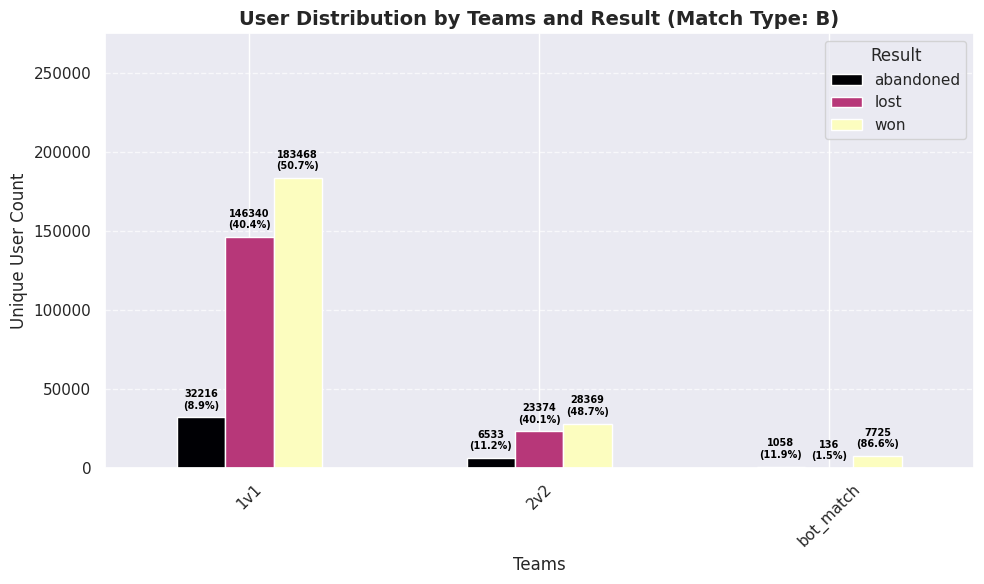

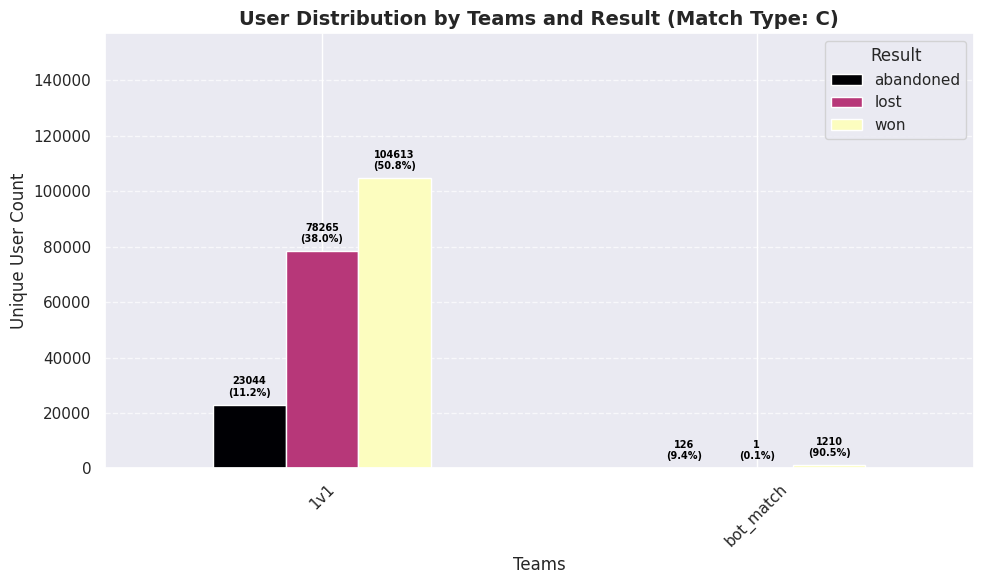

In [ ]:
#Total user Visual
unique_match_types = sorted(df['match_type'].unique())

for match_type_val in unique_match_types:
    df_filtered = df[df['match_type'] == match_type_val]

    pivot_table = df_filtered.pivot_table(
        index='teams',
        columns='result',
        values='user_id',
        aggfunc='count',
        fill_value=0
    )

    # Calculate percentages for data labels
    total_users_per_team = pivot_table.sum(axis=1)
    percentage_table = pivot_table.div(total_users_per_team, axis=0) * 100

    # Plotting
    ax = pivot_table.plot(kind='bar', stacked=False, figsize=(10, 6), colormap='magma')
    plt.title(f'User Distribution by Teams and Result (Match Type: {match_type_val})', fontsize=14, fontweight='bold')
    plt.xlabel('Teams', fontsize=12)
    plt.ylabel('Unique User Count', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Result')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Adjust y-axis limit to create space for labels
    max_y = pivot_table.max().max()
    ax.set_ylim(0, max_y * 1.5) # Increased y-limit by 50% to make more space for labels

    # Add data labels
    for i, container in enumerate(ax.containers):
        result_col_name = pivot_table.columns[i]
        labels = []
        for j, patch in enumerate(container.patches):
            height = patch.get_height()
            if height > 0:
                team_name = pivot_table.index[j]
                percentage = percentage_table.loc[team_name, result_col_name]
                labels.append(f'{int(height)}\n({percentage:.1f}%)') # Added newline character
            else:
                labels.append('')
        ax.bar_label(container, labels=labels, label_type='edge', padding=5, fontsize=7, color='black', fontweight='bold') # Increased padding slightly

    plt.tight_layout()
    plt.show()

**Monetization**


--- Product Group Insights (Sorted by Total Purchase Value) ---


,product_group,total_dollar_purchase_value,total_purchase_number,unique_users
2,Perks,6184.26,26300,600
1,Gold,1383.32,1020,146
0,Boosts,1113.69,1950,387
3,Remove Ads,105.47,61,53


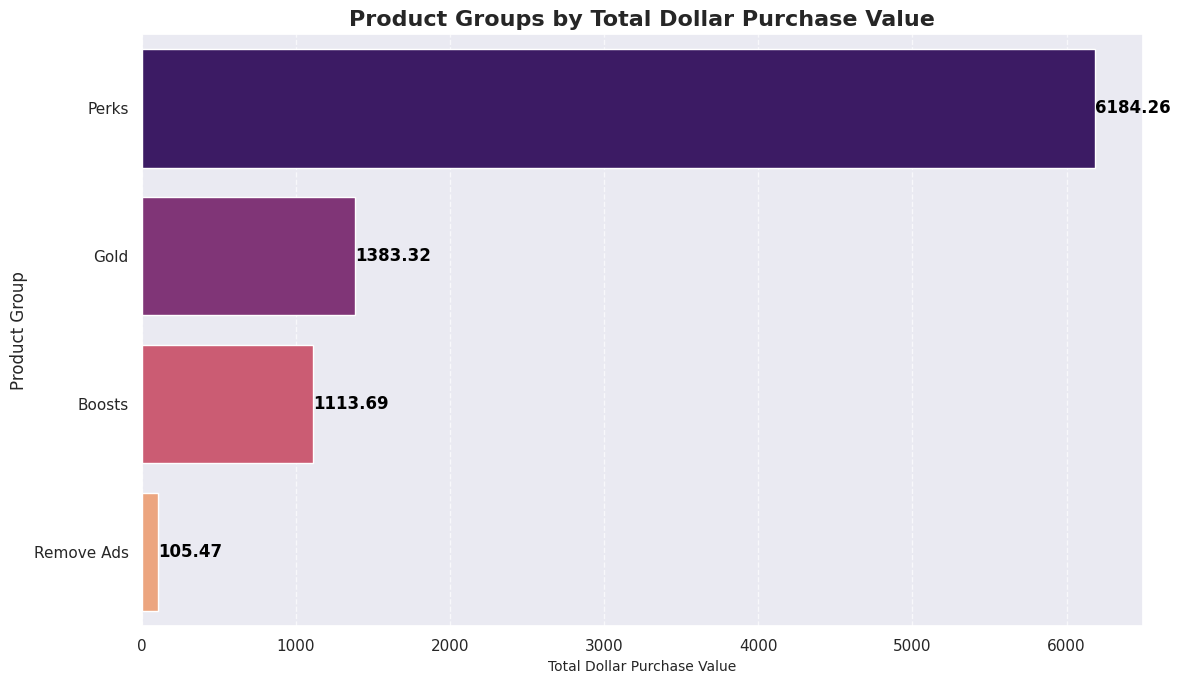

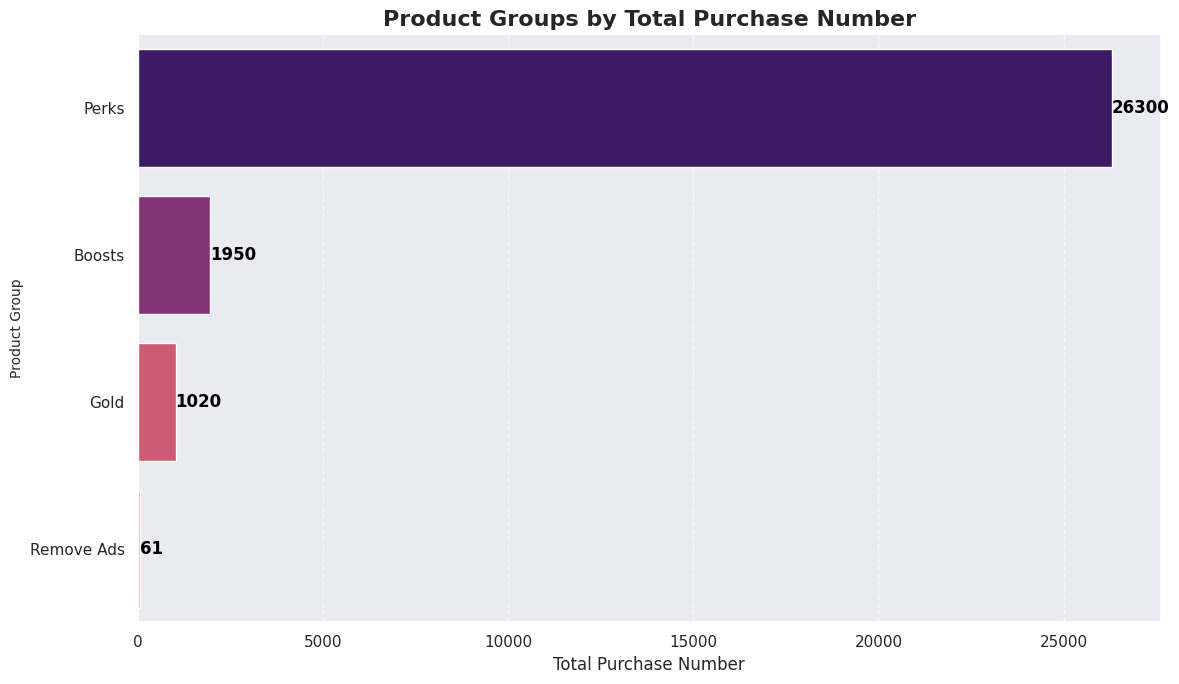

In [ ]:
#Product_group Performance

conn_iap = sqlite3.connect('iap.db')
iap_df = pd.read_sql_query("SELECT * FROM iap", conn_iap)
conn_iap.close()

# Calculate total purchase value and number of purchases per product group
product_group_insights = iap_df.groupby('product_group').agg(
    total_dollar_purchase_value=('dollar_purchase_value', 'sum'),
    total_purchase_number=('purchase_number', 'sum'),
    unique_users=('user_id', 'nunique')
).reset_index()

# Sort by total dollar purchase value for top products
product_group_insights_sorted_value = product_group_insights.sort_values(
    by='total_dollar_purchase_value', ascending=False
)
print("\n--- Product Group Insights (Sorted by Total Purchase Value) ---")
display(product_group_insights_sorted_value)


# Plotting1
plt.figure(figsize=(12, 7))
ax1 = sns.barplot(
    x='total_dollar_purchase_value', y='product_group',
    data=product_group_insights_sorted_value.head(10),
    hue='product_group', palette='magma', legend=False
)
plt.title('Product Groups by Total Dollar Purchase Value', fontsize=16, fontweight='bold')
plt.xlabel('Total Dollar Purchase Value', fontsize=10)
plt.ylabel('Product Group', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add data labels 1
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', color='black', fontweight='bold')
plt.tight_layout()
plt.show()

# Plotting 2
plt.figure(figsize=(12, 7))
ax2 = sns.barplot(
    x='total_purchase_number', y='product_group',
    data=product_group_insights_sorted_number.head(10),
    hue='product_group', palette='magma', legend=False
)
plt.title('Product Groups by Total Purchase Number', fontsize=16, fontweight='bold')
plt.xlabel('Total Purchase Number', fontsize=12)
plt.ylabel('Product Group', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add data labels 2
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d', color='black', fontweight='bold')
plt.tight_layout()
plt.show()


--- Pivot Table: Product Group vs. Dollar Purchase Value (Total User Count) ---


dollar_purchase_value,1.99,4.99,9.99,19.99,49.99,99.99
product_group,,,,,,
Boosts,512,19,0,0,0,0
Gold,223,18,11,7,6,3
Perks,1540,457,70,7,0,0
Remove Ads,53,0,0,0,0,0


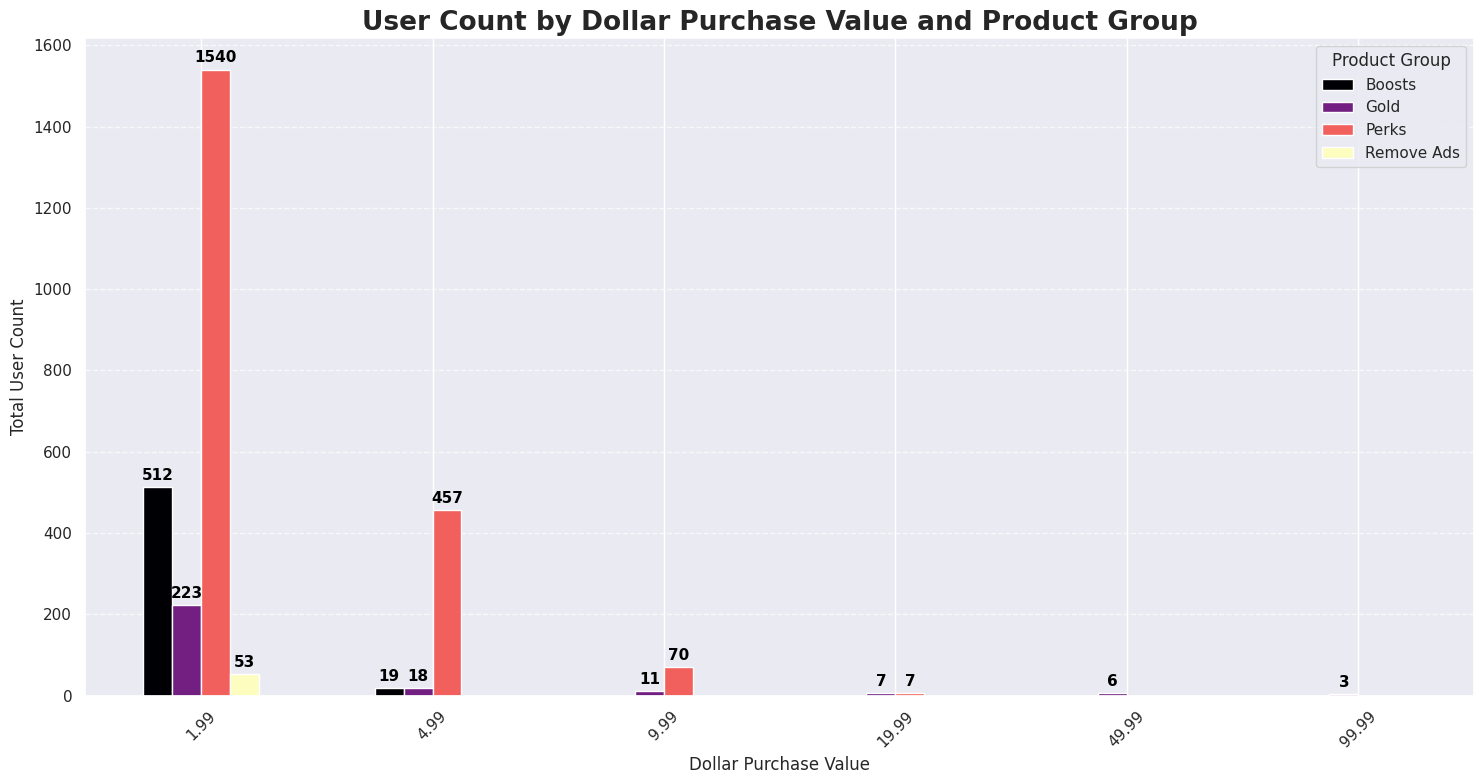

In [ ]:
#Product group by dollar purchase_value

iap_pivot_table = iap_df.pivot_table(
    index='product_group',
    columns='dollar_purchase_value',
    values='user_id',
    aggfunc='count',
    fill_value=0
)

print("\n--- Pivot Table: Product Group vs. Dollar Purchase Value (Total User Count) ---")
display(iap_pivot_table)

ax = iap_pivot_table.T.plot(kind='bar', stacked=False, figsize=(15, 8), colormap='magma')
plt.title('User Count by Dollar Purchase Value and Product Group', fontsize=19, fontweight='bold')
plt.xlabel('Dollar Purchase Value', fontsize=12)
plt.ylabel('Total User Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Product Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels
for container in ax.containers:
    labels = [f'{int(patch.get_height())}' if patch.get_height() > 0 else '' for patch in container.patches]
    ax.bar_label(container, labels=labels, label_type='edge', padding=3, fontsize=11, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

**Ads Data Analysis (Monetization)**

In [ ]:
#AD_TYPE Pivot
ads_insights = ads_df.groupby('ad_type').agg(
    user_count=('user_id', 'count'),
    total_impressions=('impressions', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()

total_overall_revenue = ads_insights['total_revenue'].sum()
ads_insights['percentage_of_total_revenue'] = (ads_insights['total_revenue'] / total_overall_revenue) * 100

display(ads_insights)

,ad_type,user_count,total_impressions,total_revenue,percentage_of_total_revenue
0,interstitial,231098,2333989,6302.143,47.302121
1,rewarded,173324,1239296,7021.029,52.697879


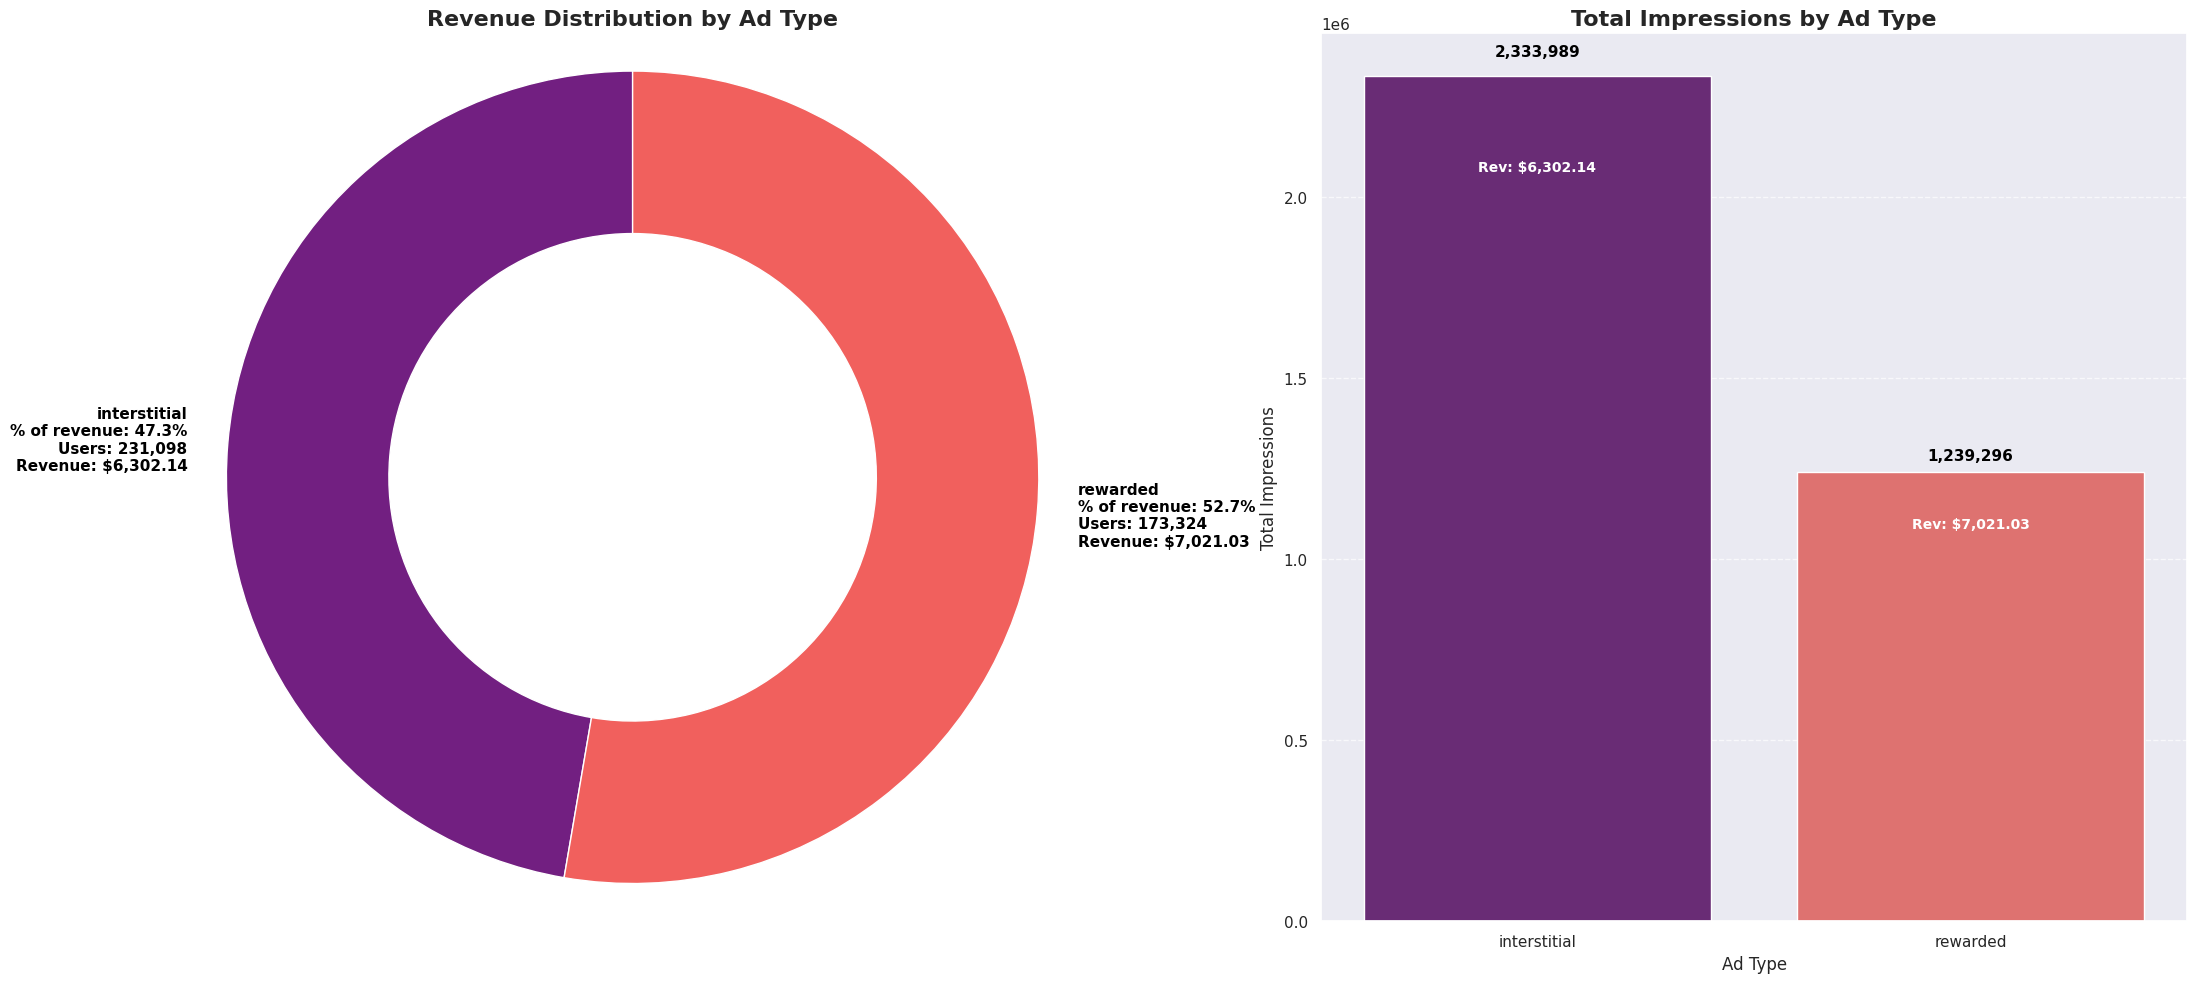

In [ ]:
#ADs visuals

n_ad_types = len(ads_insights['ad_type'])
magma_palette = sns.color_palette('magma', n_colors=n_ad_types)

# 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(22, 10)) # 1 row, 2 columns

# Plot 1 (Pie chart)

# Add labels 1
labels = ads_insights['ad_type']
percentages = ads_insights['percentage_of_total_revenue']
user_counts = ads_insights['user_count']
total_revenues = ads_insights['total_revenue']

pie_labels_combined = [
    f'{ad_type}\n% of revenue: {pct_rev:.1f}%\nUsers: {users:,}\nRevenue: ${rev:,.2f}'
    for ad_type, pct_rev, users, rev in zip(labels, percentages, user_counts, total_revenues)
]

axes[0].pie(
    ads_insights['percentage_of_total_revenue'],
    labels=pie_labels_combined,
    startangle=90,
    wedgeprops=dict(width=0.4),
    textprops={'fontsize': 11, 'color': 'black', 'fontweight': 'bold'},
    colors=magma_palette
)

axes[0].set_title('Revenue Distribution by Ad Type', fontsize=16, fontweight='bold')
axes[0].axis('equal')

# Plot 2 (Column chart)
sns.barplot(x='ad_type', y='total_impressions', data=ads_insights, hue='ad_type', palette=magma_palette, legend=False, ax=axes[1])

axes[1].set_title('Total Impressions by Ad Type', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Ad Type', fontsize=12)
axes[1].set_ylabel('Total Impressions', fontsize=12)

# Add data labels 2
for i, p in enumerate(axes[1].patches):
    ad_data = ads_insights.iloc[i]
    total_impressions = ad_data['total_impressions']
    total_revenue = ad_data['total_revenue']

    # Main label (Total Impressions)
    axes[1].annotate(f'{int(total_impressions):,}',
                (p.get_x() + p.get_width() / 2., p.get_height() * 1.02), # Slightly above the bar
                ha='center', va='bottom',
                fontsize=11, color='black', fontweight='bold')

    # Sub-label (Total Revenue)
    axes[1].annotate(f'Rev: ${total_revenue:,.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height() * 0.9), # Inside the bar, slightly down
                ha='center', va='top',
                fontsize=10, color='white', fontweight='bold')

axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()